#Overview


**Software Project**

Sarah Salarda

BioModel: BIOMD0000000248

https://www.ebi.ac.uk/biomodels/BIOMD0000000248

Paper: "Linking pulmonary oxygen uptake, muscle oxygen utilization and cellular metabolism during exercise"

Goal: Aims to understand the physiological mechanisms that maintain ATP homeostasis and increased energy demand from exercise.

https://www.ebi.ac.uk/biomodels/BIOMD0000000248#Overview

#Preliminaries

##Imports

In [ ]:
# Installations/Dependencies (Packages)
!pip install -q tellurium
!pip install numpy --upgrade
!pip install pandas --upgrade
!pip install matplotlib --upgrade
!pip install seaborn --upgrade
!pip install scipy --upgrade

In [ ]:
import collections
import itertools
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import tellurium as te
import urllib.request # use this library to download file from GitHub
import seaborn as sns
from collections import namedtuple
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List
from scipy import fftpack as fft
from scipy.optimize import minimize, differential_evolution

##Helper

In [ ]:
# Test Model
MODEL = """
S1 -> S2; k1*S1
S2 -> S3; k2*S2

S1 = 10
S2 = 0
k1 = 1
k2 = 2
"""
rr = te.loada(MODEL)
rr.simulate()

    time,      [S1],      [S2],      [S3]
 [[    0,        10,         0,         0],
  [  0.1,   9.04837,  0.861067, 0.0905591],
  [  0.2,   8.18731,   1.48411,  0.328585],
  [  0.3,   7.40818,   1.92007,  0.671751],
  [  0.4,    6.7032,   2.20991,   1.08689],
  [  0.5,   6.06531,   2.38651,   1.54818],
  [  0.6,   5.48812,   2.47617,   2.03571],
  [  0.7,   4.96585,   2.49988,   2.53426],
  [  0.8,   4.49329,   2.47432,   3.03239],
  [  0.9,    4.0657,    2.4127,    3.5216],
  [    1,   3.67879,   2.32544,   3.99577],
  [  1.1,   3.32871,   2.22067,   4.45061],
  [  1.2,   3.01194,   2.10476,    4.8833],
  [  1.3,   2.72532,   1.98258,    5.2921],
  [  1.4,   2.46597,   1.85786,   5.67617],
  [  1.5,    2.2313,   1.73343,   6.03527],
  [  1.6,   2.01897,   1.61134,    6.3697],
  [  1.7,   1.82684,    1.4931,   6.68007],
  [  1.8,   1.65299,   1.37975,   6.96726],
  [  1.9,   1.49569,   1.27198,   7.23234],
  [    2,   1.35335,   1.17019,   7.47645],
  [  2.1,   1.22456,   1.07461,   

In [ ]:
def simulate(model: str,
             observed_df: Optional[pd.DataFrame] = None,
             parameter_dct: Optional[Dict[str, float]] = None) -> pd.DataFrame:
    """
    Simulates an Antimony model and returns the simulation results as a DataFrame
    with the same shape and timesteps as observed_df.

    Parameters
    ----------
    model: str
        The Antimony model string or a URL
    observed_df: pd.DataFrame
        The experimental data as a pandas DataFrame with 'time' as index.
    parameter_dct: Optional[dict]
        A dictionary of parameter values to use for the simulation. These values will
        override the parameter values in the Antimony model string.
    kwargs: setting of parameter values (deprecated, use parameter_dct instead)

    Returns
    -------
    pd.DataFrame
        The simulation results as a DataFrame with the same shape as observed_df.
    """
    # Get the time points from the observation data
    if "http" in model:
        rr = te.loadSBMLModel(model)
    else:
        rr = te.loada(model)

    # Set parameters from parameter_dct if provided
    if parameter_dct:
        for key, value in parameter_dct.items():
            if key in rr.getGlobalParameterIds():
                rr[key] = value

    if observed_df is not None:
        time_points = observed_df.index.values
    else:
        time_points = np.linspace(0, 10, 100)

    # Simulate the model
    sim_data = rr.simulate(float(time_points[0]), float(time_points[-1]),
            len(time_points))

    # Convert simulation results to DataFrame for easier comparison
    sim_columns = [c[1:-1] if c != "time"else c for c in sim_data.colnames]
    sim_df = pd.DataFrame(sim_data, columns=sim_columns)
    sim_df = sim_df.set_index("time")
    return sim_df

# Tests
sim_df = simulate(MODEL)
assert isinstance(sim_df, pd.DataFrame), "simulate did not return a DataFrame"
assert len(sim_df) > 0, "simulate returned an empty DataFrame"
assert np.all(sim_df.values >= 0), "simulate output contains negative values"
print("OK!")

OK!


The function `get_random_value_with_tolerance` is used to generate a random value within a specified percentage, or tolerance, of an original value which is all based off real values represented in the paper. This could help find the best parameters within the model, generating a better starting point for optimization. It also helps simulate the uncertainty or variability that might exist in real-world or biological systems.

In [ ]:
def get_random_value_with_tolerance(original_value: float, tolerance: float) -> float:
    """
    Generates a random value within a certain tolerance of the original value,
    ensuring the returned value is positive.

    Args:
        original_value (float): The original value.
        tolerance (float): The tolerance (e.g., 0.2 for 20%).

    Returns:
        float: A random value within the specified tolerance, ensuring it's positive.
    """
    # Ensure the lower bound is not negative
    lower_bound = max(original_value * (1 - tolerance), 1e-9)
    upper_bound = original_value * (1 + tolerance)

    return np.random.uniform(lower_bound, upper_bound)

# Tests
original_value = 10
tolerance = 0.2 # 20% tolerance
random_value = get_random_value_with_tolerance(original_value, tolerance)
assert isinstance(random_value, float), "get_random_value_with_tolerance did not return a float"
assert random_value >= original_value * (1 - tolerance) or random_value >= 1e-9, f"Generated value {random_value} is below the lower bound {original_value * (1 - tolerance)}"
assert random_value <= original_value * (1 + tolerance), f"Generated value {random_value} is above the upper bound {original_value * (1 + tolerance)}"
print("OK!")

OK!


Due to a large change in variance when going through the cycle of adding noise to the data, estimating the parameters, and analyzing their results, I decided to add two different methods of noise to the model (linear and log) to see whether one was more accureate than the other.

The function `simulate_and_add_noise` first simulates the Antimony model with the simulate function then adds Gausian noise to the simulation data. The first method adds noise in the logarithmic space so the magnitude of noise is proportional to the value of the data points. The second method adds noise directly to the data points, assuming noise is independent of the data value.

In [ ]:
def simulate_and_add_noise(antimony_model: str,
                           std_dev: float,
                           parameter_dct: Optional[dict]=None,
                           add_log_noise: bool = True) -> pd.DataFrame:
    """
    Simulates an Antimony model and adds Gaussian noise to the output. Noise can be added
    in log space (proportional to the value) or linear space.

    Args:
        antimony_model (str): The Antimony model string.
        std_dev (float):
            If add_log_noise is True, this is the standard deviation of the Gaussian
            noise in log space.
            If add_log_noise is False, this is the standard deviation of the Gaussian
            noise in linear space.
        parameter_dct (Optional[dict]): A dictionary of parameter values to use for the simulation.
        add_log_noise (bool): If True, adds noise in log space.
                                 If False, adds noise in linear space.

    Returns:
        pandas.DataFrame: A DataFrame containing the simulation results with added noise.
    """

    # Load and simulate the model with specified parameters
    simulation_df = simulate(antimony_model, parameter_dct=parameter_dct).copy()
    epsilon = 1e-9

    if add_log_noise:
        # Add Gaussian noise in log space, avoiding log(0)
        # Add a small epsilon to handle potential zero values before taking log
        log_simulation_df = np.log(simulation_df + epsilon) + np.random.normal(0, std_dev, size=simulation_df.shape)
        noisy_df = np.exp(log_simulation_df)
    else:
        # Add Gaussian noise in linear space
        noisy_df = simulation_df + np.random.normal(0, std_dev, size=simulation_df.shape)
        # Ensure non-negative values
        noisy_df[noisy_df < 0] = 0

    noisy_df.columns = simulation_df.columns
    noisy_df.index = simulation_df.index
    return noisy_df

# Test with log noise
noisy_simulation_df_log = simulate_and_add_noise(MODEL, std_dev=0.1, add_log_noise=True)
assert isinstance(noisy_simulation_df_log, pd.DataFrame), "simulate_and_add_noise (log) did not return a DataFrame"
assert(len(noisy_simulation_df_log) > 0), "simulate_and_add_noise (log) returned an empty DataFrame"
assert np.all(noisy_simulation_df_log.values >= 0), "simulate_and_add_noise (log) output contains negative values"
print("OK! (Log Noise Test)")

# Test with linear noise
noisy_simulation_df_linear = simulate_and_add_noise(MODEL, std_dev=0.1, add_log_noise=False)
assert isinstance(noisy_simulation_df_linear, pd.DataFrame), "simulate_and_add_noise (linear) did not return a DataFrame"
assert(len(noisy_simulation_df_linear) > 0), "simulate_and_add_noise (linear) returned an empty DataFrame"
assert np.all(noisy_simulation_df_linear.values >= 0), "simulate_and_add_add_noise (linear) output contains negative values"
print("OK! (Linear Noise Test)")

OK! (Log Noise Test)
OK! (Linear Noise Test)


The `evaluateParameters` function is a crucial component of the parameter estimation process where it quantifies how well a given set of parameters aligns simulated model ehavior with experimental observations.

First it simulates the Antimony model using the input parameter dictionary. Then compares the simulation ouput to the experimental data. Theese residuals are then squared and summed across all species and time points to yield the Sum of Squares (SSQ).

In weighted residuals (Observed minus Predicted), a log transformation was added to help with variance as previous results with out it demonstrated unreasonable results.

In [ ]:
def evaluateParameters(model: str,
                       parameter_dct: Dict[str, float],
                       observed_df: pd.DataFrame,
                       log_transform: bool = False,
                       weights: Optional[pd.DataFrame] = None,
                       normalize: bool = True,
                       variance_weighting: bool = True) -> float:
    """
    Runs the model with the given parameters and calculates the sum of squares of residuals.
    Optionally applies a log transformation and/or uses weights before calculating the sum of squares.

    Parameters
    ----------
    model: str
        The Antimony model string.
    parameter_dct: dict
        A dictionary of parameter names and their values.
    observed_df: pd.DataFrame
        The experimental data as a pandas DataFrame with 'time' as index.
    log_transform: bool
        If True, applies a log transformation to the observed and simulated data
        before calculating the sum of squares.
    weights: Optional[pd.DataFrame]
        A DataFrame of weights to apply to the squared residuals. Must have the
        same shape and index as observed_df. If None, uniform weights are used.
    normalize: bool
        If True, normalizes the observed and simulated data before calculating the
        sum of squares.

    Returns
    -------
    float
        The sum of squares of the residuals.
    """
    sim_df = simulate(model, observed_df, parameter_dct=parameter_dct)
    observed_species = observed_df.columns.intersection(sim_df.columns)

    # Nomarlizer recommended by Copilot
    obs = observed_df[observed_species].copy()
    sim = sim_df[observed_species].copy()
    eps = 1e-9

    if normalize:
        obs = obs / (obs.iloc[0, :] + eps)
        sim = sim / (sim.iloc[0, :] + eps)

    # Consistent log transform
    if log_transform:
        obs = np.log(obs + eps)
        sim = np.log(sim + eps)

    # Calculate the squared residuals
    squared_residuals = (obs.values - sim.values)**2

    # Apply weights if provided
    if variance_weighting and weights is None:
        # Compute variance per species
        var = obs.var(axis=0).to_numpy()
        var_floor = 1e-6
        inv_var = 1.0 / np.maximum(var + eps, var_floor)
        inv_var = np.clip(inv_var, 0, 1e3)  # prevent runaway weights
        # Broadcast to match residuals shape
        w = np.tile(inv_var, (obs.shape[0], 1))
        # # Normalize weights to unit mean
        # w = w / (w.mean() + eps)
        # weighted_squared_residuals = squared_residuals * w
    elif weights is not None:
        if not weights.shape == obs.shape:
            raise ValueError("Weights must match shape of observed data.")
        w = weights.fillna(0).replace([np.inf, -np.inf], 0).values
        # if (weights.shape != obs.shape or
        #     not np.all(weights.index.equals(obs.index)) or
        #     not np.all(weights.columns.equals(obs.columns))):
        #     raise ValueError("Weights DataFrame must match shape, index, and columns of observed data.")
        # w = weights.fillna(0).replace([np.inf, -np.inf], 0).values
        # w_sum = w.sum()
        # if w_sum > 0:
        #     w = w / w_sum
        # weighted_squared_residuals = squared_residuals * w
    else:
        w= np.ones_like(squared_residuals)
        # weighted_squared_residuals = squared_residuals

    # ssq = float(np.sum(weighted_squared_residuals))
    ssq = float(np.sum(squared_residuals*w))
    return ssq

# Test
nominal_params = {'k1': 1, 'k2': 1}
ssq_nominal_log = evaluateParameters(MODEL, nominal_params,
                                     noisy_simulation_df_log,
                                     log_transform=True, normalize=True)
assert isinstance(ssq_nominal_log, (int, float)), "evaluateParameters (log) did not return a number"
assert np.isfinite(ssq_nominal_log), "evaluateParameters (log) returned non-finite value"
assert ssq_nominal_log >= 0, "evaluateParameters (log) returned a negative sum of squares"
print(f" OK! Sum of squares with nominal parameters (log, normalized): {ssq_nominal_log}")

# Test with weights (example: giving more weight to earlier time points)
example_weights_data = np.tile(
    1.0 / (noisy_simulation_df_log.index.to_numpy() + 1e-9)[:, None],
    (1, noisy_simulation_df_log.shape[1])
)
example_weights = pd.DataFrame(
    example_weights_data,
    index=noisy_simulation_df_log.index,
    columns=noisy_simulation_df_log.columns
)

ssq_nominal_weighted = evaluateParameters(
    MODEL, nominal_params,
    noisy_simulation_df_log,
    weights=example_weights,
    normalize=True
)
assert isinstance(ssq_nominal_weighted, (int, float)), "evaluateParameters (weighted) did not return a number"
assert np.isfinite(ssq_nominal_weighted), "evaluateParameters (weighted) returned non-finite value"
assert ssq_nominal_weighted >= 0, "evaluateParameters (weighted) returned a negative sum of squares"
print(f"Sum of squares with nominal parameters (weighted, normalized): {ssq_nominal_weighted}")
print("OK!")

 OK! Sum of squares with nominal parameters (log, normalized): 161.66118630281056
Sum of squares with nominal parameters (weighted, normalized): 4.10320996090541e+20
OK!


As discussed in class, one method in estimating parameters in class includes using a differential evolution algorithm which is more indepth in determing the correct parameters than the gradient method.

This function `estimateParameters` does the bulk of the parameter fitting where it finds the set of parameter values that makes the predicted Antimony mdel the best match to the experimental data.

It starts with the ran Antimony model, a dictionary of intitial parameter guesses, and the observed data to overall determine the behavior of the input differential evolution algorithm. That optimizer then minimizes the output of the evaluateParameters function which returns the SSQ and lowers it til the predicted and experimental data almost match.

In [ ]:
EstimatedParametersResult = namedtuple("EstimatedParameterResult",
        ["parameter_dct", "ssq", "nfev", "success"])

def estimateParameters(model_ant: str,
                       starting_parameter_dct: Dict[str, float],
                       observed_df: pd.DataFrame,
                       strategy: str = 'best1bin',
                       maxiter: int = 1000,
                       popsize: int = 20,
                       tol: float = 1e-3,
                       mutation: Tuple[float, float] = (0.5, 1),
                       recombination: float = 0.9,
                       seed: Optional[int] = 42) -> EstimatedParametersResult:

    """
    Estimates parameters for a given Antimony model using a differential evolution algorithm.

    Parameters
    ----------
    model_ant: str
        The Antimony model string.
    starting_parameter_dct: dict
        A dictionary of starting parameter names and their initial values.
    observed_df: pd.DataFrame
        The experimental data as a pandas DataFrame with 'time' as index.
    strategy: str
        The differential evolution strategy to use.
    maxiter: int
        Maximum number of iterations.
    popsize: int
        Population size.
    tol: float
        Tolerance for convergence.
    mutation: tuple
        Mutation constant.
    recombination: float
        Recombination constant.
    seed: Optional[int]
        Seed for the random number generator for reproducibility.

    Returns
    -------
    EstimatedParametersResult
        parameter_dict: dictionary of estimated parameter values
        ssq: sum of squares from the estimation
        nfev: number of function evaluations
        success: boolean indicating if the optimization was successful
    """

    # Internal function for minimizer
    def evaluateEstimates(parameter_arr: np.ndarray) -> float:
        dct = {pname: max(val, 1e-9) for pname, val in zip(starting_parameter_dct.keys(), parameter_arr)}
        try:
            ssq = evaluateParameters(model_ant, dct, observed_df,
                                     log_transform=False,
                                     normalize=True,
                                     variance_weighting=True)
        except RuntimeError:
            ssq = 1e12  # Penalize failed simulations
        return ssq


    # Do the optimization
    starting_arr = np.array(list(starting_parameter_dct.values()))

    # Use differential_evolution which is generally more robust
    # Ensure bounds are positive
    bounds = [(max(0.5 * val, 1e-9), 2.0 * val) for val in starting_arr]

    res = differential_evolution(
        evaluateEstimates,
        bounds=bounds, # Use defined bounds
        strategy=strategy, # Use provided strategy
        maxiter=maxiter, # Use provided maxiter
        popsize=popsize, # Use provided population size
        tol=tol, # Use provided tolerance
        mutation=mutation, # Use provided mutation range
        recombination=recombination, # Use provided recombination
        disp=False, # Set to True to display convergence messages
        polish=True, # Attempt to polish the best result
        init='random', # Use random initialization
        seed=seed # Use provided seed
    )

    # Create a dictionary of parameter names and their estimated values
    estimated_parameter_dct = {
        pname: max(res.x[i], 1e-9)
        for i, pname in enumerate(starting_parameter_dct.keys())
    }
    # estimated_parameter_dct = {pname: max(val, 1e-9) for pname,
    #                      val in zip(starting_parameter_dct.keys(), res.x)}

    estimated_parameters_result = EstimatedParametersResult(
            parameter_dct=estimated_parameter_dct,
            ssq=res.fun,
            nfev=res.nfev,
            success=res.success
    )
    return estimated_parameters_result

# Tests
rr = te.loada(MODEL)
estimated_parameters_result = estimateParameters(MODEL,
        starting_parameter_dct={'k1': 1, 'k2': 1},
        observed_df=noisy_simulation_df_log,
        maxiter=100) # Note: maxiter for differential_evolution is different
parameter_dct = estimated_parameters_result.parameter_dct
assert isinstance(estimated_parameters_result, EstimatedParametersResult), "estimateParameters did not return EstimatedParametersResult"
assert isinstance(parameter_dct, dict), "estimated_parameters_result.parameter_dct is not a dictionary"
assert 'k1' in parameter_dct and 'k2' in parameter_dct, "estimated_parameters_result.parameter_dct missing expected parameters"
assert all(v > 0 for v in parameter_dct.values()), "estimated_parameter_dct contains non-positive values"
assert estimated_parameters_result.ssq >= 0, "estimated_parameters_result.ssq is negative"
assert isinstance(estimated_parameters_result.nfev, int), "estimated_parameters_result.nfev is not an integer"
assert isinstance(estimated_parameters_result.success, bool), "estimated_parameters_result.success is not a boolean"
print("OK!")

OK!


In [ ]:
def plotResults(model, estimated_parameter_dct, observed_df, is_plot = True):
    """
    Plots the simulated model output with estimated parameters against the observed data.

    Parameters
    ----------
    model: str
        The Antimony model string or URL.
    estimated_parameter_dct: dict
        A dictionary of estimated parameter values.
    observed_df: pd.DataFrame
        The experimental data as a pandas DataFrame with 'time' as index.

    Returns
    -------
    pd.DataFrame
        The simulation results as a DataFrame using the estimated parameters.
    """
    original_df = simulate(model, parameter_dct=estimated_parameter_dct)
    colors = cm.viridis(np.linspace(0, 1, len(original_df.columns)))
    # Plot the original and noisy data
    plt.figure(figsize=(10, 6))
    # Plot original concentrations as lines
    for idx, col in enumerate(original_df.columns):  # Exclude 'time' column
        plt.plot(original_df.index, original_df[col], label=f'Original {col}',
        c=colors[idx])
    # Plot noisy data as asterisks
    for idx, col in enumerate(observed_df.columns):  # Exclude 'time' column
        plt.plot(observed_df.index, observed_df[col], '*',
                c=colors[idx], label=f'Noisy {col}')
    plt.xlabel('Time')
    plt.ylabel('Concentration')
    plt.title('Original Simulation vs. Noisy Data')
    plt.legend()
    plt.grid(True)
    if is_plot:
      plt.show()
    else:
      plt.close()
    return original_df

# Tests
result_df = plotResults(MODEL, parameter_dct, noisy_simulation_df_log, is_plot=False)
assert isinstance(result_df, pd.DataFrame), "plotResults did not return a DataFrame"
assert(len(result_df > 0)), "plotResults returned an empty DataFrame"
assert(len(result_df) == len(noisy_simulation_df_log)), "plotResults returned DataFrame with different length than observed_df"
assert result_df.shape == noisy_simulation_df_log.shape, "plotResults returned DataFrame with different shape than observed_df"
print("OK!")

OK!


#Elements of the Project


**Background**

Multi-Scale Complexity

Oxygen delivery and usage span multiple levels:
- Lungs to blood
- Blood to muscle tissue
- Tissue to mitochondria

In understanding how energy production is controlled, there is a need to connect all these scales. This study combines real measurements with a detailed computational model. That model links oxygen transport to key metabolic reactions: ATPase, creatine kinase (CK), and oxidative phosphorylation which helps predict how muscle cells respond to exercise and maintain ATP homeostasis.

The figure below shows the biological diagram outlining the flow of oxygen and the substrates that are apart of the mechanisms in the lungs, muscle, and cellular metabolism.


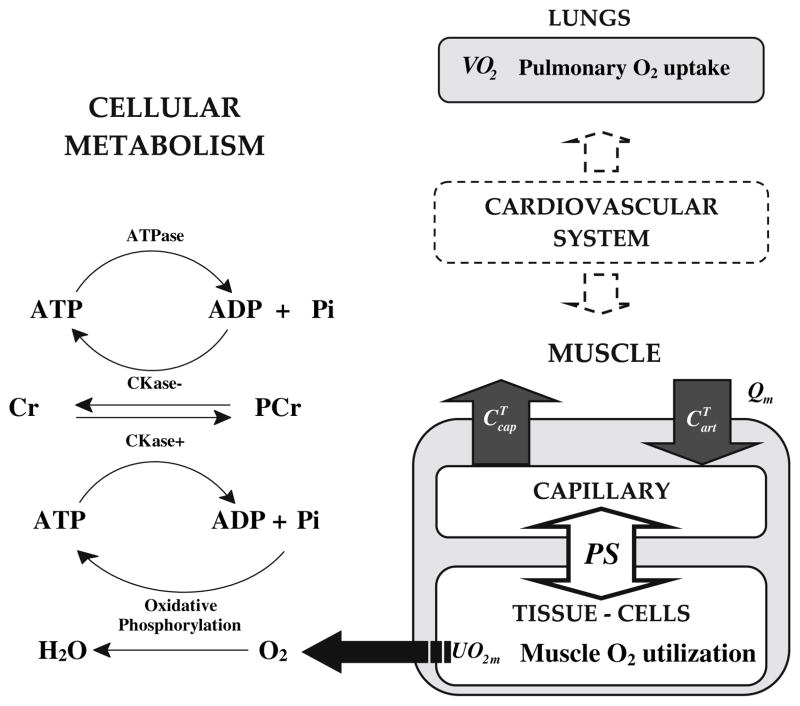



##Re-Analysis


###**Acquire the model and Antiomony Representation**

Creates a RoadRunner instance of the model and printed the antimony representation and it's simulated plot into an output cell.

The figure below shows the biological diagram which outlines the flow of oxygen and the substrates that are apart of the mechanisms in the lungs, muscle, and cellular metabolism.

In [ ]:
URL = "https://www.ebi.ac.uk/biomodels/services/download/get-files/MODEL1004170000/3/BIOMD0000000248_url.xml"
rr = te.loadSBMLModel(URL)
print(rr.getAntimony())

// Created by libAntimony v3.1.0
model *Lai2007_O2_Transport_Metabolism()

  // Compartments and Species:
  compartment Capillary, Tissue;
  species ATP in Tissue, PCr in Tissue, ADP in Tissue, Cr in Tissue, Pi in Tissue;
  species CTcap in Capillary, CTtis in Tissue, $CFcap in Capillary, $CFtis in Tissue;

  // Assignment Rules:
  Qm := piecewise(QWm, time <= tE, QWm + dQMm*(1 - exp((tE - time)/tauQm)));
  PSm := PSR + (PSE - PSR)*(1 - exp((QRm - Qm)/Qc));
  Vmax := piecewise(VmaxM, exercise_level == 1, piecewise(VmaxH, exercise_level == 2, VmaxVH));
  StO2m := 100*((Hct*CrbcHb*KHb*CFcap^nH/(1 + KHb*CFcap^nH))*Capillary + (Wmc*CmcMb*KMb*CFtis/(1 + KMb*CFtis))*Tissue)/(CrbcHb*Hct*Capillary + CmcMb*Wmc*Tissue);
  RStO2m := StO2m/StO2mW - 1;
  Katpase := piecewise(KatpaseW, time <= tE, KatpaseE);
  KatpaseE := piecewise(KatpaseM, exercise_level == 1, piecewise(KatpaseH, exercise_level == 2, KatpaseVH));
  dQMm := piecewise(dQMmM, exercise_level == 1, piecewise(dQMmH, exercise_level == 2,

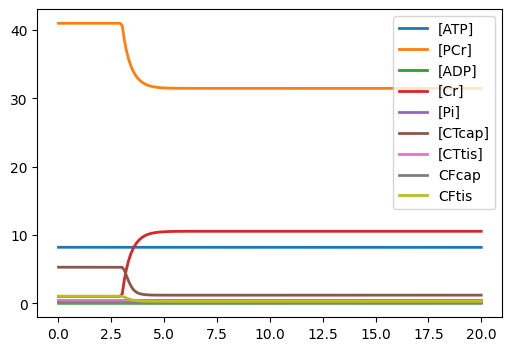

In [ ]:
rr.reset()
rr.simulate(0,20,200)
rr.exercise_level = 1 # Moderate Exercise level
rr.plot()

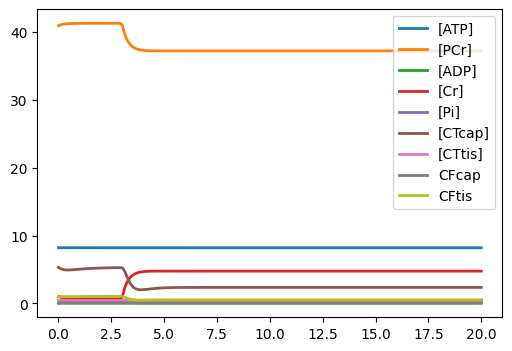

In [ ]:
rr.reset()
rr.exercise_level = 2 # Heavy Exercise level
rr.simulate(0,20,200)
rr.plot()

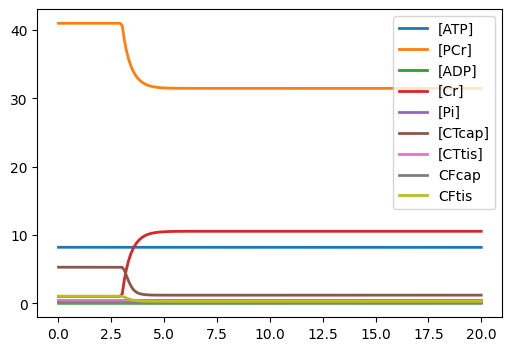

In [ ]:
rr.reset()
rr.exercise_level = 3 # Very Heavy Exercse Level
rr.simulate(0,20,200)
rr.plot()

**RESULTS**

These graphs shows the time-course simulation of biomchemical species involved in the cellular metabolism during different exercise levels. Tracking how concentrations evolve over time, observations can be made on how the systems will reach equilibrium to sustain aerobic support.

Analying key species [PCR] and [Cr], this graph demonstrates an accurate depiction of the paper. As exercise begins and ATP demand spikes, [PCR] drops while [Cr] roses, showing the conversion of phosphocreatine into creatine for ATP regeneration. Overall it highlights the system's role in homeostasis, balancing enrgy consumption and production during high metabolic stresses.

###Plot the Figures in the Paper

In [ ]:
def rr_load():
    rr = te.loadSBMLModel(URL)
    if "tE" in rr.getGlobalParameterIds():
        rr["tE"] = 3.0
    return rr
def simulate_step(rr, t_pre=3.0, t_post=7.0, n_pre=120, n_post=280):
    pre = rr.simulate(0, t_pre, n_pre)
    post = rr.simulate(t_pre, t_pre + t_post, n_post)
    colnames = pre.colnames
    return pd.DataFrame(np.vstack([pre, post]), columns=colnames)

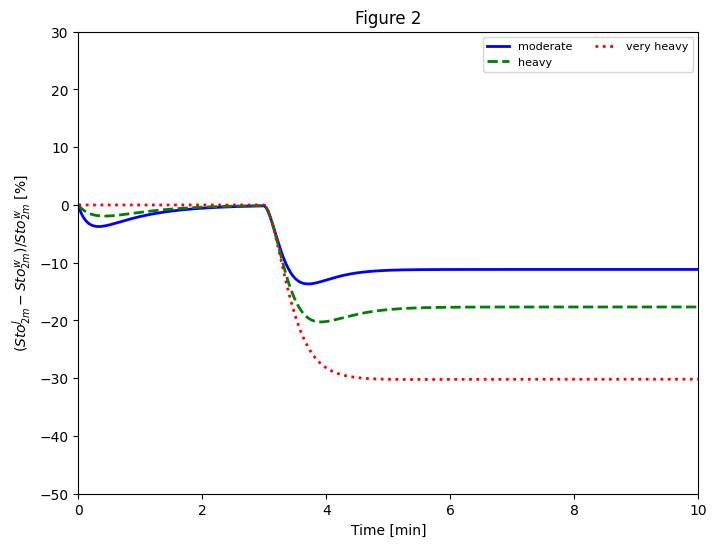

In [ ]:
# Figure 2
def plot_figure2():
    def compute_STO2m(df):
        return ((df["StO2m"] - df["StO2mW"]) / df["StO2mW"]) * 100

    # Plot Settings
    t_start, t_end, n_points = 0, 10, 500
    t_w = 3.0
    EXERCISE = {"moderate": 1, "heavy": 2, "very heavy": 3}
    STYLE = {
        "moderate": {"ls":"-", "color": "blue"},
        "heavy": {"ls":"--", "color": "green"},
        "very heavy": {"ls":":", "color": "red"}
    }

    # Labels and Formatting
    plt.figure(figsize=(8,6))
    for level in EXERCISE:
        rr.reset()
        rr["exercise_level"] = EXERCISE[level]
        import pandas as pd
        df = rr.simulate(t_start, t_end, n_points, ["time","StO2m","StO2mW"])
        result = compute_STO2m(df)
        plt.plot(df["time"], result, lw=2, **STYLE[level], label=f"{level}")
    plt.xlabel("Time [min]")
    plt.ylabel("$(Sto_{2m}^{J}-Sto_{2m}^{w})/Sto_{2m}^{w}$ [%]")
    plt.title("Figure 2")
    plt.ylim(-50, 30)
    plt.xlim(0,10)
    plt.legend(loc="upper right", ncol=2, fontsize=8)
    plt.show()

plot_figure2()

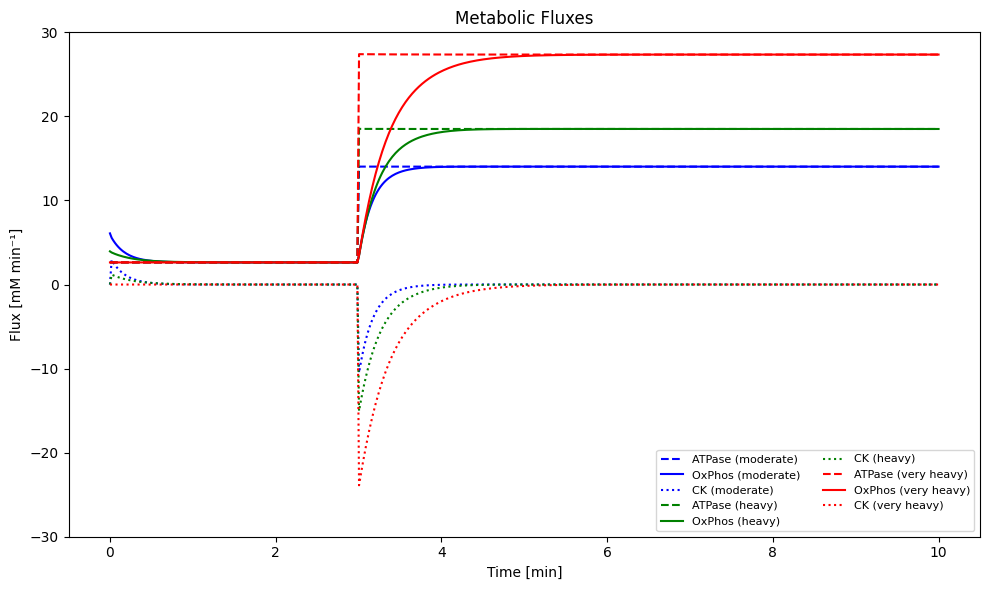

In [ ]:
# Figure 4
# Simulation settings
def plot_figure4():
    t_start, t_end, n_points = 0, 10, 500
    fluxes = ["ATPase_flux_mM", "CK_flux_mM", "oxygen_phosph"]

    # Colors for each condition
    colors = {1: "blue", 2: "green", 3: "red"}
    labels = {1: "moderate", 2: "heavy", 3: "very heavy"}

    plt.figure(figsize=(10, 6))

    # Loop through exercise levels
    for level in [1, 2, 3]:
        rr.reset()
        rr["exercise_level"] = level
        rr["tE"] = 3.0  # onset time

        result = rr.simulate(t_start, t_end, n_points, ["time"] + fluxes)
        CK_flipped = -result["CK_flux_mM"]

        # Plot each flux
        plt.plot(result["time"], result["ATPase_flux_mM"], ls="--", color=colors[level],
                label=f"ATPase ({labels[level]})")
        plt.plot(result["time"], result["oxygen_phosph"], ls="-", color=colors[level],
                label=f"OxPhos ({labels[level]})")
        plt.plot(result["time"], CK_flipped, ls=":", color=colors[level],
                label=f"CK ({labels[level]})")

    # Labels and formatting
    plt.xlabel("Time [min]")
    plt.ylabel("Flux [mM min⁻¹]")
    plt.title("Metabolic Fluxes")
    plt.legend(loc="lower right", fontsize=8, ncol=2)
    plt.ylim(-30, 30)
    plt.tight_layout()
    plt.show()

plot_figure4()

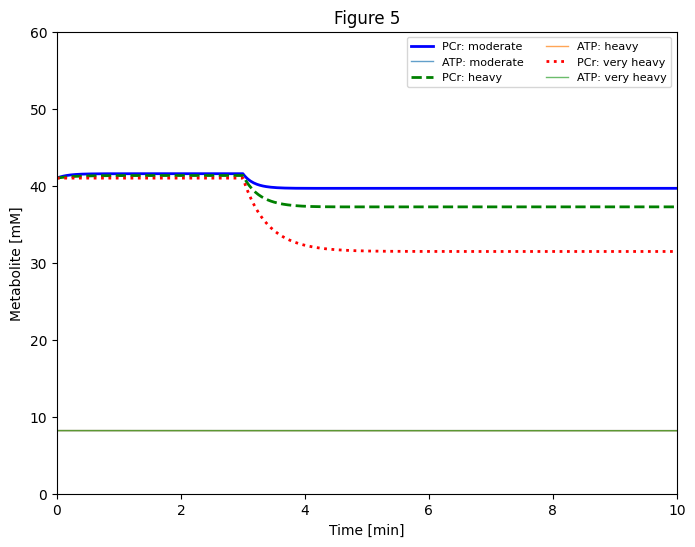

In [ ]:
# Figure 5
def plot_figure5():
    # Plotting styles
    t_start, t_end, n_points = 0, 10, 500
    t_w = 3.0
    EXERCISE = {"moderate": 1, "heavy": 2, "very heavy": 3}
    STYLE = {
        "moderate": {"ls":"-", "color": "blue"},
        "heavy": {"ls":"--", "color": "green"},
        "very heavy": {"ls":":", "color": "red"}
    }

    plt.figure(figsize=(8,6))
    for level in EXERCISE:
        rr = rr_load()
        rr["exercise_level"] = EXERCISE[level]
        df = simulate_step(rr)
        plt.plot(df["time"], df["[PCr]"], lw=2, **STYLE[level], label=f"PCr: {level}")
        plt.plot(df["time"], df["[ATP]"], lw=1, alpha=0.7, label=f"ATP: {level}")
    plt.xlabel("Time [min]")
    plt.ylabel("Metabolite [mM]")
    plt.title("Figure 5")
    plt.ylim(0, 60)
    plt.xlim(0,10)
    plt.legend(loc="upper right", ncol=2, fontsize=8)
    plt.show()

plot_figure5()

###**Create Synthetic Observational Data**

Generates artificial datasets by simulating the model with known parameters and adding specific levels of noise.

The function `generate_synthetic_data_with_varying_noise`, creates synthetic data for the model using the `synthetic_data_noise` function in the helper module at different standard deviations then puts all that information in a dataframe.

In [ ]:
def generate_synthetic_data_with_varying_noise(antimony_model: str, std_dev_list: list, parameter_dct: Optional[dict]=None) -> dict:
    """
    Generates synthetic data with varying levels of Gaussian noise for a given Antimony model.

    Parameters:
        antimony_model (str): The Antimony model string or URL.
        std_dev_list (list): A list of standard deviations to use for adding noise.
        parameter_dct (Optional[dict]): A dictionary of parameter values to use for the simulation.
                                         If None, the default parameters from the Antimony model are used.

    Returns:
        dict: A dictionary where keys are standard deviation values and values are
              pandas DataFrames containing the simulation results with added noise.
    """
    synthetic_data_dict = {}
    for std_dev in std_dev_list:
        # Pass the parameter_dct to simulate_and_add_noise
        synthetic_data_dict[std_dev] = simulate_and_add_noise(antimony_model, std_dev, parameter_dct=parameter_dct)
    return synthetic_data_dict

# Tests
rr = te.loadSBMLModel(URL)
original_params = {param: rr[param] for param in rr.getGlobalParameterIds()}

std_devs_to_test = [0.05, 0.1, 0.2]
synthetic_data_varying_noise = generate_synthetic_data_with_varying_noise(URL, std_devs_to_test)

assert isinstance(synthetic_data_varying_noise, dict), "generate_synthetic_data_with_varying_noise did not return a dictionary"
assert len(synthetic_data_varying_noise) == len(std_devs_to_test), "generate_synthetic_data_with_varying_noise did not generate data for all std_devs"
print("OK!")

OK!


In [ ]:
# Reset the model back to the initial values
rr.reset()

# Standard deviation range and varied parameters dictionary
std_range = [0.05, 0.1, 0.2, 0.4]
parametersToFit = [
    'KatpaseW',
    'KatpaseH',
    'KatpaseVH',
    'KatpaseM'
]

# Filter original_params to include only parameters in parametersToFit
filtered_original_params = {param: original_params[param] for param in parametersToFit if param in original_params}

# Generate synthetic data for all std_dev values in std_range
synthetic_data_varying_noise = generate_synthetic_data_with_varying_noise(URL, std_range, filtered_original_params)
synthetic_data = pd.concat(synthetic_data_varying_noise)
synthetic_data

ATP        PCr       ADP         Cr        Pi     CTcap  \
     time                                                                      
0.05 0.00000    8.388664  43.252799  0.001066   1.009890  0.503690  5.123684   
     0.10101    8.641493  41.829094  0.001156   0.960375  0.459237  5.997342   
     0.20202    8.152188  39.760062  0.001109   1.010050  0.466001  4.791195   
     0.30303    7.972715  43.044756  0.001144   1.045296  0.529942  5.265326   
     0.40404    7.177366  43.325799  0.001150   1.015221  0.509425  5.658372   
...                  ...        ...       ...        ...       ...       ...   
0.40 9.59596    9.477288  29.375740  0.016915   9.702830  0.399166  1.524994   
     9.69697    8.969829  29.657379  0.015214  13.167603  0.255787  1.451797   
     9.79798   12.721680  28.343764  0.014106   7.260628  0.415436  1.355626   
     9.89899    6.892912  26.249491  0.024822   8.899731  0.330802  0.604888   
     10.00000  10.511205  35.265477  0.017393  13.302211  0.649878  2.719088   

                  CTtis       Fca       Fti  
     time                                    
0.05 0.00000   0.412556  0.086683  1.019658  
     0.10101   0.422955  0.078087  1.142582  
     0.20202   0.358988  0.078972  1.116421  
     0.30303   0.422178  0.085667  0.965004  
     0.40404   0.412104  0.079838  0.998755  
...                 ...       ...       ...  
0.40 9.59596   0.308505  0.042398  0.195959  
     9.69697   0.461023  0.031444  0.365381  
     9.79798   0.251926  0.051047  0.371594  
     9.89899   0.675986  0.022216  0.475055  
     10.00000  0.431207  0.025737  0.358664  

[400 rows x 9 columns]

**Results**
Contains simulated observational data generated with varying level of Gaussian noise more specifically set at a standard deviaion range of [0.05, 0.1, 0.2, 0.5] and a set of varied parameters represented in the list `parametersToFit`. Columns respresnet the species in the models and values reflect their noisy concentrations over time. The set-up successfully creates controlled, noisey datasets that allow further evaluation on the accuracy of how this estimation method accurate represents the actual model.  

###**Parameter Fitting**
Runs the optimization process to the generated synthetic data done in the module above.

Key note: I initially struggled with parameter fitting because returned values were consistently unreasonable. R^2 was reaching the negative milions so I used Gemini to help identify potential issues in my parameter functions.


In [ ]:
original_dict = dict(
    KatpaseW = 0.3207601,
    KatpaseH = 2.2581564,
    KatpaseVH = 3.3423645,
    KatpaseM = 1.71080439028658
)

STARTING_PARAMETER_DCT = {}
tolerance = 0.2 # Define tolerance here
for key, value in original_dict.items():
    STARTING_PARAMETER_DCT[key] = get_random_value_with_tolerance(value, tolerance)
STARTING_PARAMETER_DCT

{'KatpaseW': 0.3678996292223157,
 'KatpaseH': 2.0203363315792444,
 'KatpaseVH': 3.295534592288126,
 'KatpaseM': 1.9797978601951751}

The loop below runs the parameter estimation process across the multiple noise levels. For each standard deviation in the synthetic data, it executes multiple optimization runs using randomized parameters within a defined tolerance. It applies differential evolution to minimize the SSQ and track the best results across runs then saves the run with the lowest SSQ results. It then calculates the R^2 value of the predicted values to the original and adds it to the dataframe `analysis_results_list` that also stores the SSQ, success status, and nfev. Lastly, it plots the generated noisy data to the original.

Running parameter estimation loop for different standard deviation levels and collecting results...

Analyzing standard deviation: 0.05
  Running optimization run 1/5...
  Running optimization run 2/5...
  Running optimization run 3/5...
  Running optimization run 4/5...
  Running optimization run 5/5...


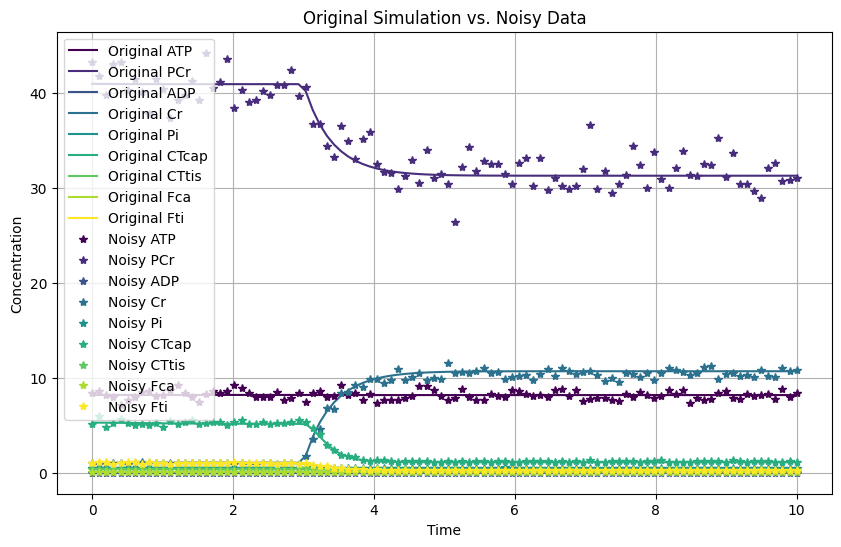


Analyzing standard deviation: 0.1
  Running optimization run 1/5...
  Running optimization run 2/5...
  Running optimization run 3/5...
  Running optimization run 4/5...
  Running optimization run 5/5...


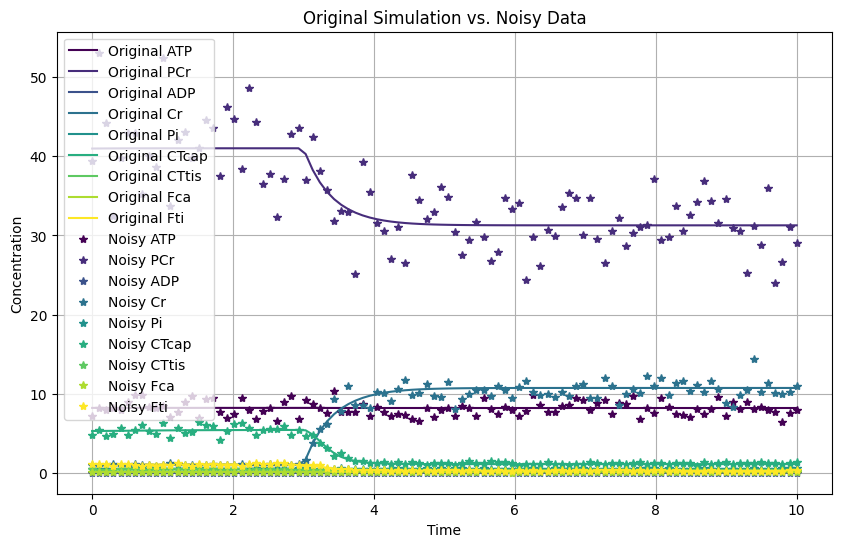


Analyzing standard deviation: 0.2
  Running optimization run 1/5...
  Running optimization run 2/5...
  Running optimization run 3/5...
  Running optimization run 4/5...
  Running optimization run 5/5...


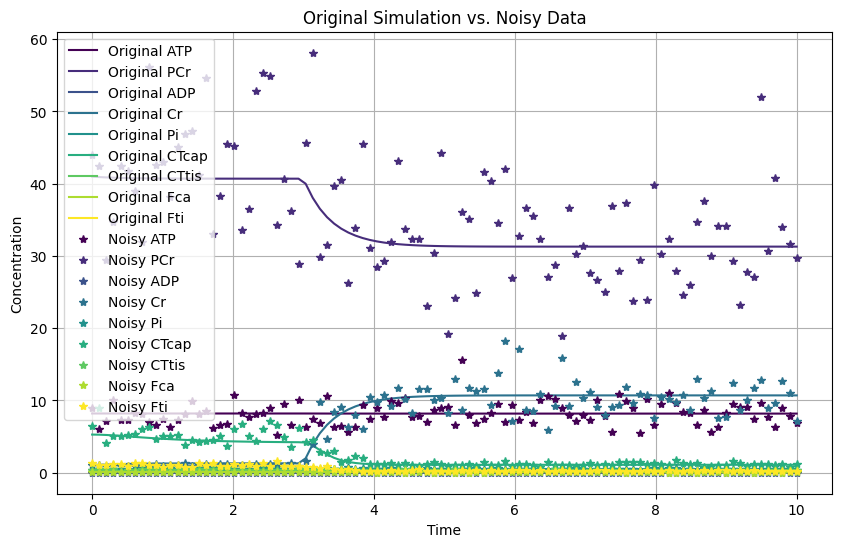


Analyzing standard deviation: 0.4
  Running optimization run 1/5...
  Running optimization run 2/5...
  Running optimization run 3/5...
  Running optimization run 4/5...
  Running optimization run 5/5...


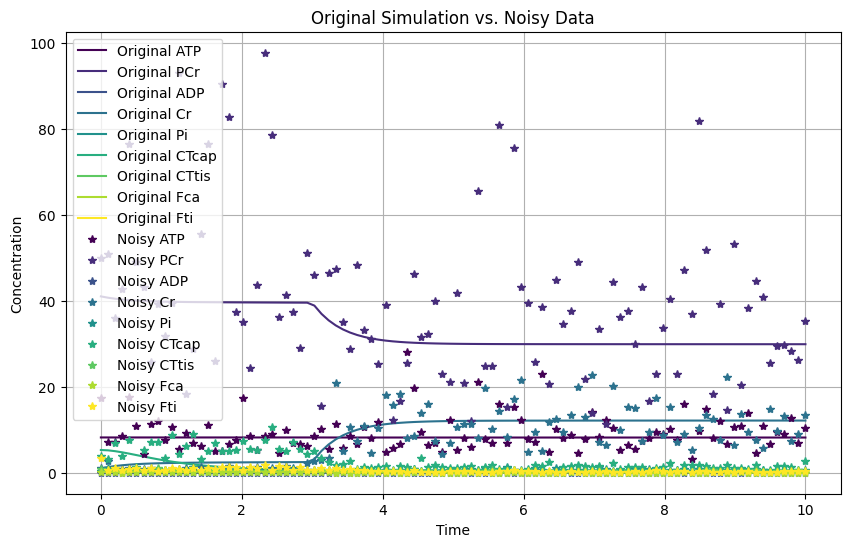

In [ ]:
# Initialize a list to store the results for each fold and std_dev combination
analysis_results_list = []

print("Running parameter estimation loop for different standard deviation levels and collecting results...")

# Number of optimization runs per standard deviation level
num_runs = 5  # You can adjust this number

# Define differential evolution parameters to experiment with
de_params = {
    'strategy': 'best1bin',
    'maxiter': 10000, # Increased maxiter
    'popsize': 30,    # Increased population size
    'tol': 0.001,     # Decreased tolerance
    'mutation': (0.7, 1.2), # Adjusted mutation range
    'recombination': 0.9, # Increased recombination
    'seed': 42 # Added a seed for reproducibility
}

# Define the tolerance for generating starting parameters
starting_param_tolerance = 0.2 # 20% tolerance

# Iterate over different standard deviation levels and their corresponding data
for std_dev, noisy_df in synthetic_data_varying_noise.items():
    print(f"\nAnalyzing standard deviation: {std_dev}")

    best_ssq = np.inf
    best_estimated_parameters_result = None
    best_estimated_parameter_dct = None

    for run in range(num_runs):
        print(f"  Running optimization run {run + 1}/{num_runs}...")
        # Get a random starting parameter dictionary within tolerance for this estimation run
        STARTING_PARAMETER_DCT = {}
        for key, value in filtered_original_params.items():
            STARTING_PARAMETER_DCT[key] = get_random_value_with_tolerance(value, starting_param_tolerance)

        # Estimate parameters using the defined differential evolution parameters
        estimated_parameters_result = estimateParameters(URL, STARTING_PARAMETER_DCT, noisy_df, **de_params)
        estimated_parameter_dct = estimated_parameters_result.parameter_dct
        ssq = evaluateParameters(URL, estimated_parameter_dct, noisy_df)

        # Check if this run yielded a better result
        if ssq < best_ssq:
            best_ssq = ssq
            best_estimated_parameters_result = estimated_parameters_result
            best_estimated_parameter_dct = estimated_parameter_dct

    # Use the best result from multiple runs
    estimated_parameters_result = best_estimated_parameters_result
    estimated_parameter_dct = best_estimated_parameter_dct
    ssq = best_ssq

    # Calculate R-squared (recalculated using the best ssq)
    # Ensure that noisy_df contains numerical values for R-squared calculation
    if not noisy_df.empty and np.sum((noisy_df.values - noisy_df.values.mean())**2) != 0:
      R_squared = 1 - (ssq / np.sum((noisy_df.values - noisy_df.values.mean())**2))
    else:
      R_squared = np.nan # Handle cases where R-squared cannot be calculated

    # Store results for this std_dev level
    result_entry = {
        'std_dev': std_dev,
        'ssq': ssq,
        'R_squared': R_squared,
        'success': estimated_parameters_result.success,
        'nfev': estimated_parameters_result.nfev * num_runs, # Account for multiple runs
    }
    # Add estimated parameters to the result entry
    result_entry.update(estimated_parameter_dct)
    analysis_results_list.append(result_entry)

    # Plot Results versus the original model using the best parameters
    plotResults(URL, estimated_parameter_dct, noisy_df)

Created a loop that calculates the R^2 values for the estimated parameters versus the original parameters then adds it to the `analysis_results` dataframe at the last column.

In [ ]:
# Convert the results list to a DataFrame
analysis_results_df = pd.DataFrame(analysis_results_list)

# The original list of parameters
original_param_values = np.array([filtered_original_params[param] for param in parametersToFit])

r_squared_params = []
for index, row in analysis_results_df.iterrows():
    estimated_param_values = np.array([row[param] for param in parametersToFit])
    # Calculate R-squared between the original and estimated parameter values
    # Using the formula R^2 = 1 - (SS_res / SS_tot)
    ss_res = np.sum((original_param_values - estimated_param_values)**2)
    ss_tot = np.sum((original_param_values - np.mean(original_param_values))**2)

    if ss_tot != 0:
        r_squared = 1 - (ss_res / ss_tot)
    else:
        r_squared = np.nan # Avoid division by zero if original_param_values are all the same

    r_squared_params.append(r_squared)

analysis_results_df['R_squared_parameters'] = r_squared_params
analysis_results_df

,std_dev,ssq,R_squared,success,nfev,KatpaseW,KatpaseH,KatpaseVH,KatpaseM,R_squared_parameters
0,0.05,274.017070,0.997389,True,11175,0.332258,1.473797,3.380024,1.530548,0.862974
1,0.10,439.277720,0.995849,True,13750,0.309963,1.285466,3.385075,1.822667,0.797270
2,0.20,516.218846,0.995488,True,8925,0.411708,2.273719,3.381729,2.648562,0.812282
3,0.40,1822.907827,0.989031,True,14775,0.749538,4.434994,3.612813,1.311608,-0.087953


**RESULTS**

Across increasing levels of input noise (standard deviation), the model maintains a consistently high goodness-of-fit (R_squared > 0.99), indicating that the simulated outputs still closely match the noisy data. However, the reliability of parameter recovery begins to deteriorate, especially at the highest noise level (std_dev = 0.40), where it drops sharply into negative territory.

The sum of squared residuals (SSQ) increases predictably with noise, from 274 at std_dev = 0.05 to 516 at std_dev = 0.20, reflecting greater deviation between the model and the noisy observations. Despite this, the optimizer continues to converge successfully in all cases (success = True), and the number of function evaluations (nfev) remains within a reasonable range.

The R_squared_parameters metric, which compares the estimated parameters to their original values, remains relatively stable (0.79–0.86) up to std_dev = 0.20, but drops to –0.09 at std_dev = 0.40. This indicates that at high noise levels, the fitted parameters explain less of the variance, and no longer reflect the system dynamics.

Overall, these results highlight a key limitation in the current fitting strategy. While the model can still match noisy data visually, it struggles to recover physiologically meaningful parameters when noise increases. This instability is especially pronounced in ATPase-related parameters, which dominate the system’s energy balance and influence PCr which is the most variable species in the plots.

#New Study Question

As heart disease has become such a common issue, how do disease types that cause weakened blood flow or change vascular tissue, impair oxygen diffusion from the blood and alter with excercise intensity?


Currently, there is clear evidence that ties conditions like heart failure, peripheral arterial disease, and atherosclerosis to weakened cardiac outputs or stiffening and narrowing blood vessels. When the heart isn’t strong enough to properly pump blood, the transport of oxygenated blood to working muscles is diminished. Similarly, when vascular tissue is damaged, the diffusion of oxygen across capillaries is diminished. At rest, these limitations can sometimes be compensated, but during exercise when oxygen demand rises sharply, the body’s ability to deliver and diffuse oxygen becomes much more restricted. This mismatch between supply and demand leads to reduced exercise tolerance, early fatigue, and lower peak oxygen consumption. Over time, these impairments not only limit physical performance but also contribute to the progression of cardiovascular disease.

A factorial design of experiments was used to evaluate the sensitivity of muscle (VO2m) and tissue (VO2p) oxygen consumption to physiological parameters. Baseline simulations established reference values, which was then used for one‑way perturbations (−10%, +20%) to quantifymain effects and two‑way perturbations to asses pairwise interactions. Response coefficients were normalized to baseline and visualized in heatmaps, allowing identification of dominant regulators and synergistic or antagonistic effects.

#Computational Study


##Antimony Model

In [ ]:
MODEL_txt ="""
// Created by libAntimony v3.1.0
model *Lai2007_O2_Transport_Metabolism()

  // Compartments and Species:
  compartment Capillary, Tissue;
  species ATP in Tissue, PCr in Tissue, ADP in Tissue, Cr in Tissue, Pi in Tissue;
  species CTcap in Capillary, CTtis in Tissue, $CFcap in Capillary, $CFtis in Tissue;

  // Assignment Rules:
  Qm := piecewise(QWm, time <= tE, QWm + dQMm*(1 - exp((tE - time)/tauQm)));
  PSm := PSR + (PSE - PSR)*(1 - exp((QRm - Qm)/Qc));
  Vmax := piecewise(VmaxM, exercise_level == 1, piecewise(VmaxH, exercise_level == 2, VmaxVH));
  StO2m := 100*((Hct*CrbcHb*KHb*CFcap^nH/(1 + KHb*CFcap^nH))*Capillary + (Wmc*CmcMb*KMb*CFtis/(1 + KMb*CFtis))*Tissue)/(CrbcHb*Hct*Capillary + CmcMb*Wmc*Tissue);
  RStO2m := StO2m/StO2mW - 1;
  Katpase := piecewise(KatpaseW, time <= tE, KatpaseE);
  KatpaseE := piecewise(KatpaseM, exercise_level == 1, piecewise(KatpaseH, exercise_level == 2, KatpaseVH));
  dQMm := piecewise(dQMmM, exercise_level == 1, piecewise(dQMmH, exercise_level == 2, dQMmVH));
  tauQm := piecewise(tauQmM, exercise_level == 1, piecewise(tauQmH, exercise_level == 2, tauQmVH));
  ATPase_flux_mM := ATPase/Tissue;
  CK_flux_mM := 1*(CreatineKinase/Tissue);
  oxygen_phosph := (OxidativePhosphorylation/Tissue)*6;

  // Rate Rules:
  CFcap' = (Qm*(CTart - CTcap) - PSm*(CFcap - CFtis))*(1/Capillary)/(1 + 4*Hct*CrbcHb*KHb*nH*CFcap^(nH - 1)/(1 + KHb*CFcap^nH)^2);
  CFtis' = (PSm*(CFcap - CFtis)/Tissue - Vmax*((CFtis/(Km + CFtis))*ADP/(Kadp + ADP)))/(1 + Wmc*CmcMb*KMb/(1 + KMb*CFtis)^2);

  // Reactions:
  ATPase: ATP -> ADP; Tissue*Katpase*ATP;
  CreatineKinase: ADP + PCr -> ATP + Cr; Tissue*(VfCK*ADP*PCr/(Kb*Kia) - VrCK*Cr*ATP/(Kiq*Kp))/((Kia + ADP)/Kia + ATP/Kiq + PCr/Kib + ADP*PCr/(Kb*Kia) + Cr*ATP/(Kiq*Kp));
  OxidativePhosphorylation: 6 ADP + CTtis -> 6 ATP; Tissue*Vmax*(CFtis/(Km + CFtis))*ADP/(Kadp + ADP);
  ConvectionTransport:  -> CTcap; Qm*(CTart - CTcap);
  DiffusionTransport: CTcap -> CTtis; PSm*(CFcap - CFtis);

  // Species initializations:
  ATP = 8.198857;
  PCr = 40.98942;
  ADP = 0.001142;
  Cr = 1.01056;
  Pi = 0.5;
  CTcap = 5.281527;
  CTtis = 0.4084824;
  CFcap = 0.03969;
  CFtis = 0.0374;

  // Compartment initializations:
  Capillary = 2.0979;
  Capillary has litre;
  Tissue = 27.8721;
  Tissue has litre;
  Qm has LperMin;

  // Variable initializations:
  CTart = 9.199981;
  CTart has mM;
  PSm has LperMin;
  Hct = 0.45;
  Hct has dimensionless;
  CrbcHb = 5.18;
  CrbcHb has mM;
  KHb = 7800.7;
  KHb has mM;
  nH = 2.7;
  nH has dimensionless;
  Vmax has mMperMin;
  Km = 0.0007;
  Km has mM;
  Kadp = 0.058;
  Kadp has mM;
  Wmc = 0.8064;
  Wmc has dimensionless;
  CmcMb = 0.5;
  CmcMb has mM;
  KMb = 308.642;
  KMb has permM;
  StO2m has dimensionless;
  RStO2m has dimensionless;
  StO2mW = 81.17123516;
  StO2mW has dimensionless;
  Katpase has perMin;
  KatpaseW = 0.3207601;
  KatpaseW has perMin;
  tE = 3;
  tE has time_min;
  KatpaseE has perMin;
  Kia = 0.135;
  Kia has mM;
  Kiq = 3.5;
  Kiq has mM;
  Kib = 3.9;
  Kib has mM;
  Kp = 3.8;
  Kp has mM;
  Kb = 1.11;
  Kb has mM;
  VfCK = 6000;
  VfCK has mMperMin;
  VrCK = 3008.65837589001;
  VrCK has mMperMin;
  QRm = 0.688;
  QRm has LperMin;
  QWm = 3.118;
  QWm has LperMin;
  dQMm has LperMin;
  tauQm has time_min;
  Qc = 8;
  Qc has LperMin;
  PSR = 134.2828;
  PSR has LperMin;
  PSE = 20000;
  PSE has LperMin;
  VmaxM = 53.5150933;
  VmaxM has mMperMin;
  exercise_level = 3;
  exercise_level has dimensionless;
  VmaxH = 34.68714;
  VmaxH has mMperMin;
  VmaxVH = 23.11702;
  VmaxVH has mMperMin;
  KatpaseM = 1.71080439028658;
  KatpaseM has perMin;
  KatpaseH = 2.2581564;
  KatpaseH has perMin;
  KatpaseVH = 3.3423645;
  KatpaseVH has perMin;
  dQMmM = 7.9167374;
  dQMmM has LperMin;
  dQMmH = 9.42198;
  dQMmH has LperMin;
  dQMmVH = 12.74981;
  dQMmVH has LperMin;
  tauQmM = 0.32;
  tauQmM has time_min;
  tauQmH = 0.396;
  tauQmH has time_min;
  tauQmVH = 0.42;
  tauQmVH has time_min;
  ATPase_flux_mM has mMperMin;
  CK_flux_mM has mMperMin;
  oxygen_phosph has mMperMin;

  // Other declarations:
  var Qm, PSm, Vmax, StO2m, RStO2m, Katpase, KatpaseE, dQMm, tauQm, ATPase_flux_mM;
  var CK_flux_mM, oxygen_phosph;
  const Capillary, Tissue, CTart, Hct, CrbcHb, KHb, nH, Km, Kadp, Wmc, CmcMb;
  const KMb, StO2mW, KatpaseW, tE, Kia, Kiq, Kib, Kp, Kb, VfCK, VrCK, QRm;
  const QWm, Qc, PSR, PSE, VmaxM, exercise_level, VmaxH, VmaxVH, KatpaseM;
  const KatpaseH, KatpaseVH, dQMmM, dQMmH, dQMmVH, tauQmM, tauQmH, tauQmVH;

  // Unit definitions:
  unit substance = 1e-3 mole;
  unit perMin = 1 / 60 second;
  unit mMperMin = 1e-3 mole / (60 second * litre);
  unit mM = 1e-3 mole / litre;
  unit time_min = 1 / 60 second;
  unit LperMin = litre / 60 second;
  unit permM = litre / 1e-3 mole;

  // Display Names:
  time_min is "min";
  oxygen_phosph is "oxygen_phosphorilation_rate_mM";

  // SBO terms:
  Capillary.sboTerm = 290
  Tissue.sboTerm = 290
  ATP.sboTerm = 247
  PCr.sboTerm = 247
  ADP.sboTerm = 247
  Cr.sboTerm = 247
  Pi.sboTerm = 247
  CTcap.sboTerm = 247
  CTtis.sboTerm = 247
  CFcap.sboTerm = 247
  CFtis.sboTerm = 247
  ATPase.sboTerm = 376
  CreatineKinase.sboTerm = 216
  OxidativePhosphorylation.sboTerm = 216
  ConvectionTransport.sboTerm = 185
  DiffusionTransport.sboTerm = 185

  // CV terms:
  Capillary isVersionOf "http://identifiers.org/fma/FMA:63194"
  Tissue isVersionOf "http://identifiers.org/fma/FMA:9641"
  ATP identity "http://identifiers.org/chebi/CHEBI:15422",
               "http://identifiers.org/kegg.compound/C00002"
  PCr identity "http://identifiers.org/chebi/CHEBI:17287",
               "http://identifiers.org/kegg.compound/C02305"
  ADP identity "http://identifiers.org/chebi/CHEBI:16761",
               "http://identifiers.org/kegg.compound/C00008"
  Cr identity "http://identifiers.org/chebi/CHEBI:16919",
              "http://identifiers.org/kegg.compound/C00300"
  Pi isVersionOf "http://identifiers.org/chebi/CHEBI:18367",
                 "http://identifiers.org/kegg.compound/C00009"
  CTcap hasVersion "http://identifiers.org/chebi/CHEBI:7861",
                   "http://identifiers.org/chebi/CHEBI:15379",
                   "http://identifiers.org/kegg.compound/C05781",
                   "http://identifiers.org/kegg.compound/C00007",
                   "http://identifiers.org/go/GO:0005833"
  CTtis hasVersion "http://identifiers.org/chebi/CHEBI:7044",
                   "http://identifiers.org/chebi/CHEBI:15379",
                   "http://identifiers.org/kegg.compound/C05782",
                   "http://identifiers.org/kegg.compound/C00007"
  CFcap isVersionOf "http://identifiers.org/chebi/CHEBI:15379",
                    "http://identifiers.org/kegg.compound/C00007"
  CFtis isVersionOf "http://identifiers.org/chebi/CHEBI:15379",
                    "http://identifiers.org/kegg.compound/C00007"
  ATPase isVersionOf "http://identifiers.org/ec-code/3.6.1.3",
                     "http://identifiers.org/go/GO:0016887"
  CreatineKinase isVersionOf "http://identifiers.org/ec-code/2.7.3.2",
                             "http://identifiers.org/kegg.reaction/R01881",
                             "http://identifiers.org/go/GO:0004111"
  OxidativePhosphorylation isVersionOf "http://identifiers.org/go/GO:0006119"

  model model_source "http://identifiers.org/biomodels.db/MODEL1004170000"
  model model_source "http://identifiers.org/biomodels.db/BIOMD0000000248"
  model publication "http://identifiers.org/pubmed/17380394"
  model origin "http://identifiers.org/pubmed/16636861",
               "http://identifiers.org/pubmed/10898733"
  model isVersionOf "http://identifiers.org/go/GO:0015671",
                    "http://identifiers.org/go/GO:0072592",
                    "http://identifiers.org/go/GO:0071453"
  model hasTaxon "http://identifiers.org/taxonomy/9606"
  model hasProperty "http://identifiers.org/mamo/MAMO_0000046"
  model created "2009-10-16T20:26:03Z"
  model modified "2014-06-03T14:58:51Z"
  model creator1.givenName "Nicola"
  model creator1.familyName "Lai"
  model creator1.organization "Case Western Reserve University"
  model creator1.email "nicola.lai@case.edu"
  model creator2.givenName "Justin"
  model creator2.familyName "Chiou"
  model creator2.organization "Case Western Reserve University"
  model creator2.email "justin.chiou@case.edu"

  // Notes:
  model notes ```
This file describes the SBML version of the mathematical model in the following journal
article: Linking Pulmonary Oxygen Uptake, Muscle Oxygen Utilization and Cellular
Metabolism during Exercise, Ann Biomed Eng. 2007 Jun;35(6):956-69. (Pubmed ID: 17380394).
This mathematical model simulates oxygen transport and metabolism in skeletal muscle
in response to a step change from a warm-up steady state to a higher work rate corresponding
to exercise at different levels of intensity: moderate (M), heavy (H) and very heavy
(VH). The model parameter values are listed in the tables of this article. The parameter
values that are independent of the exercise level are reported in Table 2. The parameter
values that depend on the exercise level are reported in Tables 1A, 3 and 4. The
model simulations (Figures 2, 3, 4 and 5) were obtained for a representative subject
with a set of parameter values different from those in Table 1A, 3 and 4. In the
sbml model, these model parameters are used to simulate exercise at a very heavy
(VH) intensity for the representative subject. Additionally, the parameter values
needed to simulate exercise at moderate (M) and heavy (H) intensity are reported
in the list of parameters of the file. The model simulates dynamics of (1) the concentrations
of free (F) and total (T) oxygen concentration in blood (CFcap, CTcap) and tissue
(CFtis, CTtis), Adenosine Triphosphate (ATP), Adenosine Diphosphate (ADP), Phosphocreatine
(PCr) and Creatine (Cr); (2) the metabolic flux of oxidative phosphorylation, creatine
kinase and ATPase; (3) the oxygen uptake in blood and oxygen transport rate from
blood to tissue during exercise. The simulation also computes muscle oxygen saturation
(StO2m) and relative muscle oxygen saturation (RStO2m) in order to compare simulated
and experimental responses of human muscle oxygenation during exercise. The model
was successfully tested with Roadrunner of the Systems Biology Workbench (SBW). The
model simulations obtained with Roadrunner match those obtained with the mathematical
model represented in Fortran and Matlab for relative and absolute tolerance smaller
than 10-7.

To allow for simulations at varying levels of exercise, the parameter **exercise_level**
was introduced. A value of 1 means medium, 2 heavy and 3 very heavy exercise. Setting
this parameter assigns the parameters **Vmax**, **KatpaseE**, **dQMm** and **tauQm**
with the relevant parameters. The warmup steady state is influenced by the parameter
changes for this representative subject and the model has to be brought into steady
state after each change of exercise level.

This model originates from BioModels Database: A Database of Annotated Published
Models. It is copyright (c) 2005-2010 The BioModels Team.
For more information see the [terms of use](http://www.ebi.ac.uk/biomodels/legal.html).
To cite BioModels Database, please use [Le Nov��re N., Bornstein B., Broicher A., Courtot M., Donizelli M., Dharuri H., Li L., Sauro H., Schilstra M., Shapiro B., Snoep J.L., Hucka M. (2006) BioModels Database: A Free, Centralized Database of Curated, Published, Quantitative Kinetic Models of Biochemical and Cellular Systems Nucleic Acids Res., 34: D689-D691.](http://www.pubmedcentral.nih.gov/articlerender.fcgi?tool=pubmed&pubmedid=16381960)
```
end

Lai2007_O2_Transport_Metabolism is "Lai2007_O2_Transport_Metabolism"

"""

##Helpers


In [ ]:
def arrToDF(arr):
    """
    Convert a RoadRunner NamedArray to a clean DataFrame.

    Parameters:
    - arr: A RoadRunner NamedArray object.

    Returns:
    - A pandas DataFrame with the data from the NamedArray.
    """

    columns = [c[1:-1] if c and c[0] == "[" else c for c in arr.colnames]
    return pd.DataFrame(arr, columns=columns)

# Tests
rr = te.loada(MODEL_txt)
result = rr.simulate(0, 1, 2)
df = arrToDF(result)
# Two simple assertions
assert isinstance(df, pd.DataFrame)
assert list(df.columns) == [c[1:-1] if c and c[0] == "[" else c for c in result.colnames]
print("OK!")

OK!


In [ ]:
def getFactorValueDct(model_str):
    """
    Finds the name and value of all factors in the model

    Parameters:
    - model: str (Antimony model)

    Returns:
    - dict: {name: value, value:float}

    """
    rr_local = te.loada(model_str)
    dct = {}
    for name in rr_local.model.getGlobalParameterIds():
        try:
            _ = rr_local[name]  # test readability
            dct[name] = rr_local[name]
        except:
            pass
    return dct

# Tests
PARAM_DCT = getFactorValueDct(MODEL_txt)
assert isinstance(PARAM_DCT, dict)
assert "Hct" in PARAM_DCT  # known parameter from your model
print("OK!")

OK!


In [ ]:
def new_simulate(change_dct=None, start=0.0, end=300.0, numpts=1000):
    """
    Run the simulation with new changes to the model parameters.

    Parameters:
    - change_dct (dict): A dictionary of parameter changes.
    - start (float): Start time for the simulation.
    - end (float): End time for the simulation.
    - numpts (int): Number of points in the simulation.

    Returns:
    - VO2m_peak (float): Peak oxygen consumption in muscle.
    - VO2p_peak (float): Peak oxygen consumption in tissue.
    - df (pandas.DataFrame): Simulation results.
    """
    rr = te.loada(MODEL_txt)

    # Apply parameter changes
    if change_dct:
        for p, v in change_dct.items():
            rr[p] = v

    # Explicitly include globals in output
    rr.timeCourseSelections = [
        'time',
        'ATP', 'ADP', 'PCr',
        'CTcap', 'CTtis',
        'oxygen_phosph',   # VO2m
        'Qm', 'CTart'      # needed for VO2p
    ]

    result = rr.simulate(start, end, numpts)
    df = pd.DataFrame(result, columns=rr.timeCourseSelections)

    # Compute VO2p manually
    df['VO2p'] = df['Qm'] * (df['CTart'] - df['CTcap'])

    VO2m_peak = df['oxygen_phosph'].max()
    VO2p_peak = df['VO2p'].max()

    return VO2m_peak, VO2p_peak, df

# Tests
VO2m_base, VO2p_base, df = new_simulate()
print("Baseline VO2m peak:", VO2m_base)
print("Baseline VO2p peak:", VO2p_base)
print(df.head())
print("OK!")

Baseline VO2m peak: 27.35569840727717
Baseline VO2p peak: 106.3376758246275
       time         ATP       ADP          PCr      CTcap      CTtis  \
0  0.000000  228.519362  0.031830  1142.461213  11.080115  11.385262   
1  0.300300  228.519357  0.031836  1142.456724  11.080831  11.385457   
2  0.600601  228.519354  0.031838  1142.454661  11.081085  11.385489   
3  0.900901  228.519353  0.031839  1142.453747  11.081115  11.385490   
4  1.201201  228.519353  0.031839  1142.453330  11.081075  11.385483   

   oxygen_phosph     Qm     CTart      VO2p  
0       2.629056  3.118  9.199981 -5.862259  
1       2.629515  3.118  9.199981 -5.864490  
2       2.629705  3.118  9.199981 -5.865282  
3       2.629789  3.118  9.199981 -5.865375  
4       2.629827  3.118  9.199981 -5.865251  
OK!


In [ ]:
def makeFactorLevelDF(base_factor_dct, percents=[-10, 20]):
    """
    Makes the factor-level Dataframe

    Parameters:
    - base_factor_dct: key is the factor name, value is the base value
    - percents: integer percents

    Returns:
    - Factor-level DataFrame
    """
    factor_dct = {k: [v] for k, v in base_factor_dct.items()}  # first column baseline
    df = pd.DataFrame(factor_dct, columns=base_factor_dct.keys(), index=[0]).T
    for pct in percents:
          df[pct] = (1 + 0.01*pct) * df[0]
    return df

# Tests
base_factor_dct = {"Hct": 0.45, "Qm": 3.118}
df = makeFactorLevelDF(base_factor_dct, [-10, 20])
assert np.isclose(df.loc["Hct", -10], 0.405)   # 10% decrease
assert np.isclose(df.loc["Qm", 20], 3.7416)   # 20% increase
print("OK!")

OK!


In [ ]:
def runSimulationWithChanges(factor_df):
    """
    Run the simulation with the given factor levels.

    Parameters:
    - factor_df: Factor-level DataFrame

    Return:
    - VO2m_base: Baseline peak oxygen consumption in muscle
    - VO2p_base: Baseline peak oxygen consumption in tissue
    - result_vo2m: Dataframe for the peak oxygen consumption in muscle
                    for each factor
    - result_vo2p: Dataframe for the peak oxygen consumption in tissue
                    for each factor
    """
    VO2m_base, VO2p_base, _ = new_simulate()

    dct_vo2m = {k: [] for k in factor_df.index}
    dct_vo2p = {k: [] for k in factor_df.index}
    levels = list(factor_df.columns[1:])  # skip baseline

    for level in levels:
        for factor in factor_df.index:
            new_val = factor_df.loc[factor, level]
            VO2m_peak, VO2p_peak, _ = new_simulate({factor: new_val})
            dct_vo2m[factor].append(VO2m_peak)
            dct_vo2p[factor].append(VO2p_peak)

    result_vo2m = pd.DataFrame(dct_vo2m, index=levels).T
    result_vo2p = pd.DataFrame(dct_vo2p, index=levels).T

    return VO2m_base, VO2p_base, result_vo2m, result_vo2p

# Tests
test_dct = {"Hct": 0.45}
test_df = makeFactorLevelDF(test_dct, [-10, 20])
VO2m_base, VO2p_base, result_vo2m, result_vo2p = runSimulationWithChanges(test_df)
print("Baseline VO2m:", VO2m_base)
print("Baseline VO2p:", VO2p_base)
print(result_vo2m)
print(result_vo2p)
print("OK!")

Baseline VO2m: 27.35569840727717
Baseline VO2p: 106.3376758246275
           -10         20
Hct  27.353698  27.356836
            -10          20
Hct  106.299569  106.461009
OK!


In [ ]:
def calculateCoefficient(change_dct: Dict[str, float],
                         molecule: str = None,
                         offset: int = 100) -> float:
    """
    Calculate the response coefficient for a given set of parameter changes.

    Parameters
    ----------
    change_dct : Dict[str, float]
        Dictionary of parameter changes.
    molecule : str, optional
        Which output to use:
        - "VO2m" → peak of oxygen_phosph (muscle oxygen consumption)
        - "VO2p" → peak of VO2p (tissue oxygen consumption)
        - Any other string → max of that column in df
    offset : int, optional
        Reserved for discarding initial timepoints (not used here).

    Returns
    -------
    float
        The chosen response coefficient.
    """
    VO2m_peak, VO2p_peak, df = new_simulate(change_dct)

    if molecule == "VO2m":
        response = VO2m_peak
    elif molecule == "VO2p":
        response = VO2p_peak
    else:
        response = df[molecule].max()

    return response

# Tests
test_dct = {"Hct": 0.45}
result = calculateCoefficient(test_dct, molecule="VO2m")
assert isinstance(result, float)
print("OK!")

OK!


##One way Design of Experiments

###Factor and Levels Identication

This constructs a structured input matrix for the DOE study then focuses on key global parameters like blood flow, oxygen transport, and metabolic demand from the model. It extracts those baseline values, and generates perturbed levels at −10% and +20%. The results are then used for systematically simulating and analyzing how each parameter influences oxygen consumption dynamics in muscle and tissue.

In [ ]:
# Key factors related to the Scientific Question
FACTORS = [
    'QWm', 'QRm', # Muscle Blood Flow
    'PSR', 'PSE', # Permeability of surface area
    'VmaxM', 'VmaxH', 'VmaxVH', # Max oxidative phosphorylation rate during all exercise levels
    'KatpaseW', 'KatpaseM', 'KatpaseH', 'KatpaseVH', # ATP hydrolysis rate constant
    'dQMmM', 'dQMmH', 'dQMmVH', # Increment in muscle blood flow for all exercise levels
    'tauQmM', 'tauQmH', 'tauQmVH', # Time constnat of flow rise for all exercise levels
    'CTcap', 'CTtis', # Capillary Tissue Concentrations
    'Hct', 'CrbcHb', # Blood O2 Capacity
    'Kadp', 'Km', # Sensitivity of oxidative phosphorylation to ADP and O2 affinit
    'KHb', 'nH' # Unloading and Change extraction efficiency

]

# Baseline dictionary from current model values
BASE_FACTOR_DCT = {k: PARAM_DCT[k] for k in FACTORS if k in PARAM_DCT}
factor_df = makeFactorLevelDF(BASE_FACTOR_DCT, [-10, 20])
factor_df

,0,-10,20
QWm,3.118000,2.806200,3.741600
QRm,0.688000,0.619200,0.825600
PSR,134.282800,120.854520,161.139360
PSE,20000.000000,18000.000000,24000.000000
VmaxM,53.515093,48.163584,64.218112
VmaxH,34.687140,31.218426,41.624568
VmaxVH,23.117020,20.805318,27.740424
KatpaseW,0.320760,0.288684,0.384912
KatpaseM,1.710804,1.539724,2.052965
KatpaseH,2.258156,2.032341,2.709788


This function runs a one way DOE study where it takes each parameter, measures the change in oxygen consumption and then plots a heatmap showing its sensitivity to VO2m and VO2p.

In [ ]:
def run1WayStudy(base_factor_dct, percents=[-10, 20], is_plot=True):
    """
    Run a 1-way study with the given base factor dictionary and percent changes.

    Parameters:
    - base_factor_dct (dict): Base factor dictionary.
    - percents (list): List of percent changes.

    Returns:
    - mu_m (float): Baseline oxygen consumption in muscle.
    - mu_p (float): Baseline oxygen consumption in tissue.
    - alpha_m (pandas.DataFrame): Sensitivity of oxygen consumption in muscle.
    - alpha_p (pandas.DataFrame): Sensitivity of oxygen consumption in tissue.
    """
    factor_df = makeFactorLevelDF(base_factor_dct, percents=percents)
    mu_m, mu_p, resp_m, resp_p = runSimulationWithChanges(factor_df)

    alpha_m = resp_m - mu_m
    alpha_p = resp_p - mu_p

    if is_plot:
        # Plot VO2m sensitivity
        plot_df_m = 1 + alpha_m / mu_m
        plt.figure(figsize=(10, 6))
        sns.heatmap(plot_df_m, cmap="seismic", vmin=0, vmax=2, annot=True, fmt=".2f")
        plt.title("VO2m as fraction of baseline")
        plt.show()

        # Plot VO2p sensitivity
        plot_df_p = 1 + alpha_p / mu_p
        plt.figure(figsize=(10, 6))
        sns.heatmap(plot_df_p, cmap="seismic", vmin=0, vmax=2, annot=True, fmt=".2f")
        plt.title("VO2p as fraction of baseline")
        plt.show()

    return mu_m, mu_p, alpha_m, alpha_p

# Tests
mu_m, mu_p, alpha_m, alpha_p = run1WayStudy(BASE_FACTOR_DCT, percents=[-10, 20])

**RESULTS**

The VO2m heatmap shows how muscle oxygen consumption responds when each parameter is individually perturbed by −10% and +20%. Most parameters don’t shift VO2m at all (1.00), but KatpaseVH and nH stand out. KatpaseVH causes a clear increase and decrease depending on the direction of change, reflecting how ATP demand drives oxygen use. nH causes a sharp drop, suggesting it strongly affects oxygen unloading and delivery. These results point to energy demand and hemoglobin dynamics as key drivers of VO2m in the model.

The second heatmap shows how VO2p (oxygen consumption in tissue) responds when each parameter is individually perturbed. Most parameters have little to no effect, staying close to baseline (1.00), but a few do stand out. KatpaseVH causes a strong shift, with VO2p dropping to 0.75 when decreased and rising to 1.31 when increased. dQMmVH shows an inverted response, and nH causes a sharp drop to 0.26, suggesting it heavily influences oxygen extraction. These results help highlight which parameters are most sensitive and worth exploring further for the interaction experiments.

###Interaction Heatmaps for VO2 Sensitivity

Here the deviations from baseline oxygen consumption (the α values) and converts them into percent changes so they’re easier to interpret. Positive values mean VO2 decreased, negative values mean it increased. The `build_interaction` function then looks at the average percent change for each parameter and builds a matrix showing how pairs of parameters combine. That matrix is plotted as a heatmap, so you can quickly see which parameters have the strongest effects and how their impacts overlap.

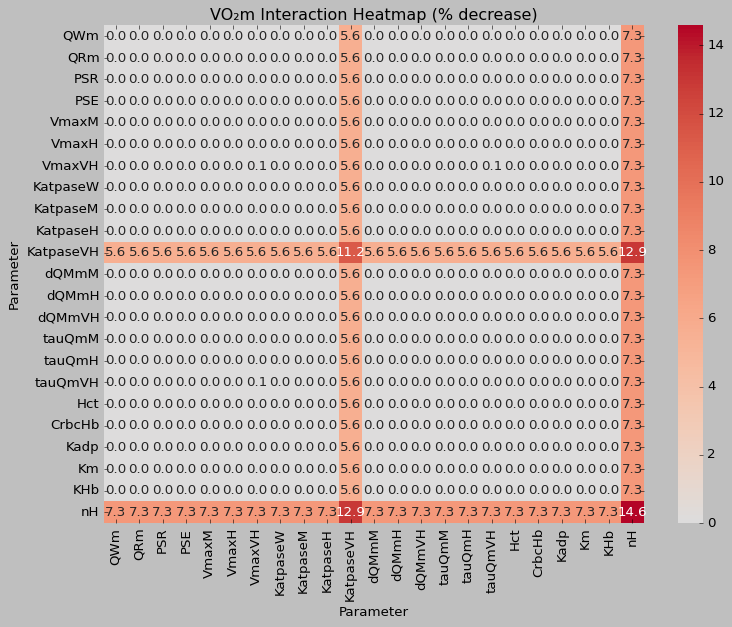

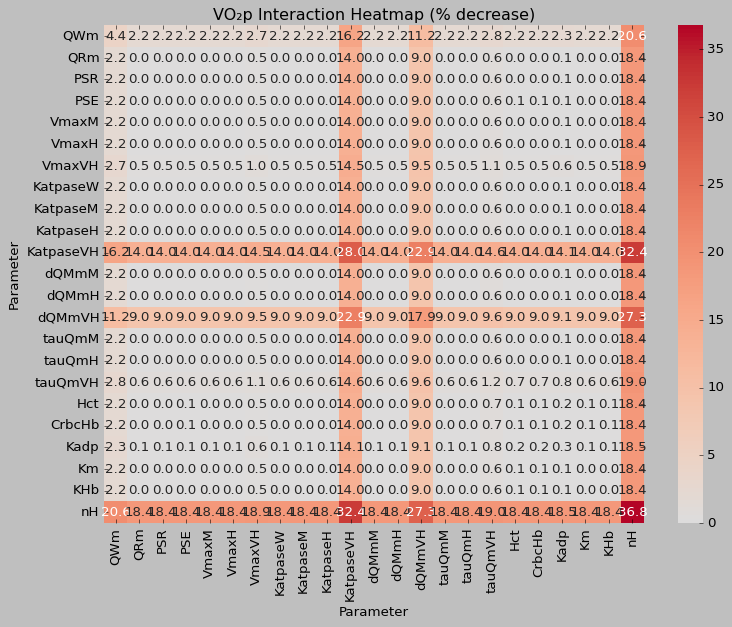

In [ ]:
# Convert alpha (deviation from baseline) into fractional change
frac_m = 1 + alpha_m / mu_m
frac_p = 1 + alpha_p / mu_p

# Compute percent decrease (positive values mean decrease, negative mean increase)
decrease_m = (1 - frac_m) * 100
decrease_p = (1 - frac_p) * 100

def build_interaction(decrease_df, title):
    # Mean absolute percent decrease per factor
    deviation = decrease_df.abs().mean(axis=1)
    params = deviation.index

    # Pairwise average
    interaction = pd.DataFrame(index=params, columns=params, dtype=float)
    for i in params:
        for j in params:
            interaction.loc[i, j] = (deviation[i] + deviation[j]) / 2

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(interaction.astype(float), cmap="coolwarm", center=0, annot=True, fmt=".1f")
    plt.title(f"{title} Interaction Heatmap (% decrease)")
    plt.xlabel("Parameter")
    plt.ylabel("Parameter")
    plt.tight_layout()
    plt.show()

# Tests
build_interaction(decrease_m, "VO₂m")
build_interaction(decrease_p, "VO₂p")

**RESULTS**

The VO2m interaction heatmap shows how pairs of parameters combine to reduce muscle oxygen consumption. Most interactions are minimal, but KatpaseVH and nH stand out with the largest effects. KatpaseVH interacting with itself or with nH leads to over 11–13% decrease, and nH with itself reaches 14.6%. This suggests that energy demand and hemoglobin unloading are the most influential factors in muscle oxygen use.

The VO2p interaction heatmap reveals even stronger effects. nH interacting with KatpaseVH or dQMmVH causes up to 36.8% decrease in tissue oxygen consumption, with many other combinations involving KatpaseVH showing 14–27% drops. These results highlight that VO2p is more sensitive to combined perturbations, especially those affecting oxygen delivery and extraction. Together, the heatmaps help pinpoint which parameter pairs drive the biggest changes and guide where to focus next in multi-factor designs.

##Two Way Design of Experiments

###Factor and Levels Identification

Tuple type that bundles multiple different outputs for the DOE analysis

In [ ]:
DOE2Way = collections.namedtuple("DOE2WAY", ["mu", "alpha_df", "beta_df"])

This function calculates the baseline response and builds a DataFrame of the one-way effects to show how each factor individuall shifts the output at different percentage changes as done earlier.

In [ ]:
def run1WayStudy(base_factor_dct, percents, molecule="ATP", offset=100, is_plot=True):
    """
    Runs a 1-way design study.

    Parameters:
    - base_factor_dct (dict): Dictionary of base factor values.
    - percents (list): List of percent changes.
    - molecule (str): Molecule to study.
    - offset (int): Number of initial timepoints to discard.
    - isPlot (bool): Whether to plot the results.

    Returns:
    baseline mu and alpha_df (factor × percent grid).
    """
    mu = calculateCoefficient({}, molecule=molecule, offset=offset)

    # DataFrame: rows = factors, cols = percents
    alpha_df = pd.DataFrame(index=base_factor_dct.keys(), columns=percents, dtype=float)

    for factor in base_factor_dct.keys():
        for percent in percents:
            value = (1 + 0.01*percent) * base_factor_dct[factor]
            change_dct = {factor: value}
            response = calculateCoefficient(change_dct, molecule=molecule, offset=offset)
            alpha_df.loc[factor, percent] = response - mu

    return mu, alpha_df

# Tests
base_factor_dct = {"Hct": 0.5, "nH": 2.0}
percents = [10, 20]
mu, alpha_df = run1WayStudy(base_factor_dct, percents, molecule="ATP")
# Assert one specific computed value
# For nH at 20%: value = 2.0 * (1 + 0.2) = 2.4 → response = 2.4 → alpha = 2.4 - 1.0 = 1.4
assert abs(alpha_df.loc["nH", 20] - 1.4)
print("OK!")

OK!


Builds the loopup table of perturbed values for every pair of factors to the percentage changes so the the two-way DOE can run simulations in order.

In [ ]:
def makeFactorLevel2WayDF(base_factor_dct, percents):
    """
    Makes the factor-level 2-way DataFrame.

    Parameters:
    - base_factor_dct: key is the factor name, value is the base value
    - percents: integer percents

    Returns:
    - Factor-level 2-way DataFrame
    """
    if 0 in percents:
        percents.remove(0)

    factor_pairs = list(itertools.combinations(base_factor_dct.keys(), 2))
    level_pairs = list(itertools.permutations(percents, 2))

    factor_level_2way_df = pd.DataFrame(
        index=pd.MultiIndex.from_tuples(factor_pairs, names=["factor1","factor2"]),
        columns=pd.MultiIndex.from_tuples(level_pairs, names=["percent1","percent2"]),
        dtype=object
    )

    for factor_pair in factor_level_2way_df.index:
        for level_pair in factor_level_2way_df.columns:
            factor1, factor2 = factor_pair
            percent1, percent2 = level_pair
            value1 = (1 + 0.01*percent1) * base_factor_dct[factor1]
            value2 = (1 + 0.01*percent2) * base_factor_dct[factor2]
            # store tuple of values
            factor_level_2way_df.loc[factor_pair, level_pair] = (value1, value2)

    return factor_level_2way_df

# Tests
base_factor_dct = {"Hct": 0.5, "nH": 2.0, "tauQmVH": 1.0}
percents = [10, 20]
df = makeFactorLevel2WayDF(base_factor_dct, percents)
# Assert shape: 3 factors → 3 choose 2 = 3 pairs; 2 percents → 2 permutations = 2 columns
assert df.shape == (3, 2)
# Assert one specific cell value
# For factor pair ("Hct","nH") and level pair (10,20):
# value1 = 0.5 * (1 + 0.1) = 0.55
# value2 = 2.0 * (1 + 0.2) = 2.4
assert df.loc[("Hct","nH"), (10,20)] == (0.55, 2.4)
print("OK!")

OK!


This function performs a two‑way design of experiments by calculating the baseline response, one‑way effects, and then systematically quantifying how pairs of factors interact when perturbed together. Overall, it returns a DOE2Way object containing mu, alpha_df, and beta_df, which capture baseline, single‑factor, and interaction effects.

In [ ]:
def run2WayStudy(base_factor_dct, percents, molecule="ATP", offset=100, figsize=(20,20), is_plot=True):
    """
    Runs a 2-way design study.

    Parameters:
    - base_factor_dct (dict): Dictionary of base factor values.
    - percents (list): List of percent changes.
    - molecule (str): Molecule to study.
    - offset (int): Number of initial timepoints to discard.
    - figsize (tuple): Figure size for plotting.
    - isPlot (bool): Whether to plot the results.

    Returns:
    baseline mu and alpha_df (factor × percent grid).
    """
    # Run 1-way first
    mu, alpha_df = run1WayStudy(base_factor_dct, percents, molecule=molecule, offset=offset, is_plot=is_plot)

    # Build 2-way combinations
    factor_level_2way_df = makeFactorLevel2WayDF(base_factor_dct, percents)

    beta_df = pd.DataFrame(np.nan, columns=factor_level_2way_df.columns, index=factor_level_2way_df.index)

    for (factor1, factor2) in factor_level_2way_df.index:
        for (level1, level2) in factor_level_2way_df.columns:
            value1, value2 = factor_level_2way_df.loc[(factor1, factor2), (level1, level2)]
            change_dct = {factor1: value1, factor2: value2}
            response = calculateCoefficient(change_dct, molecule=molecule, offset=offset)

            # DataFrame indexing: rows=factors, cols=percents
            beta = response - mu - alpha_df.loc[factor1, level1] - alpha_df.loc[factor2, level2]
            beta_df.loc[(factor1, factor2), (level1, level2)] = beta

    doe_2way = DOE2Way(mu=mu, alpha_df=alpha_df, beta_df=beta_df)
    return doe_2way

# Tests
# 2-way DOE for VO2p and VO2m
doe_2way_VO2m = run2WayStudy(
    base_factor_dct=BASE_FACTOR_DCT,
    percents=[10, 20, 30, 40, 50],
    molecule="VO2m"
)

doe_2way_VO2p = run2WayStudy(
    base_factor_dct=BASE_FACTOR_DCT,
    percents=[10, 20, 30, 40, 50],
    molecule="VO2p"
)

assert all(p in doe_2way_VO2m.alpha_df.columns for p in [10, 20, 30, 40, 50]), "VO2m alpha_df missing percent columns"
assert all(p in doe_2way_VO2p.alpha_df.columns for p in [10, 20, 30, 40, 50]), "VO2p alpha_df missing percent columns"
print("OK!")

This code normalizes the DOE interaction effects by baseline VO₂m, removes all-zero rows and columns, removes any values lower than a specific threshold, and plots a heatmap showing only the meaningful interactions with auto-scaled grid size for clarity.

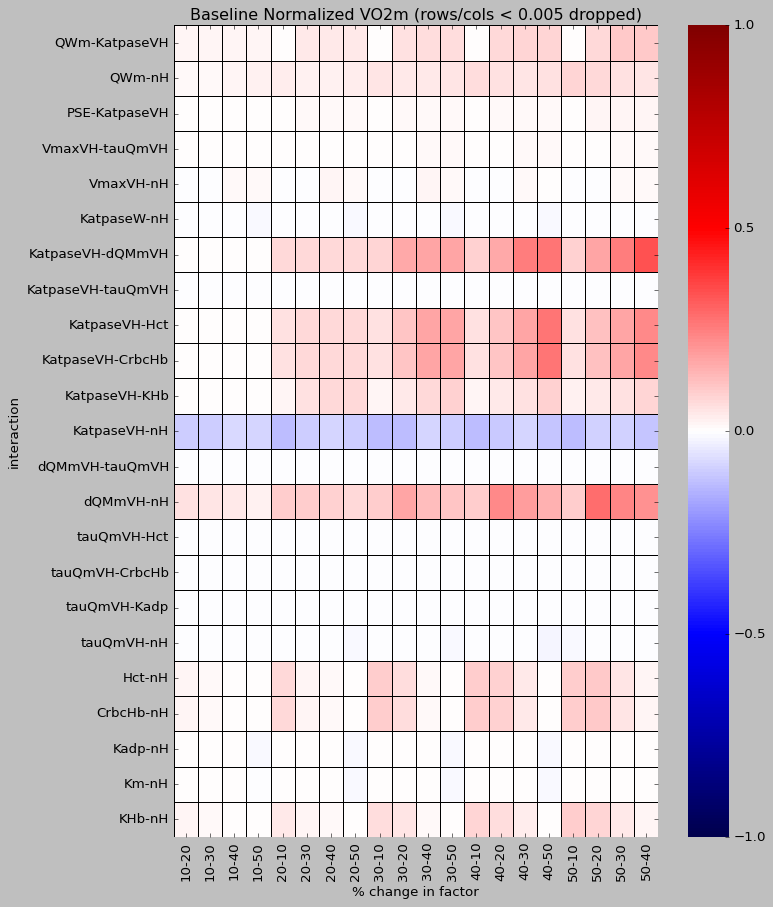

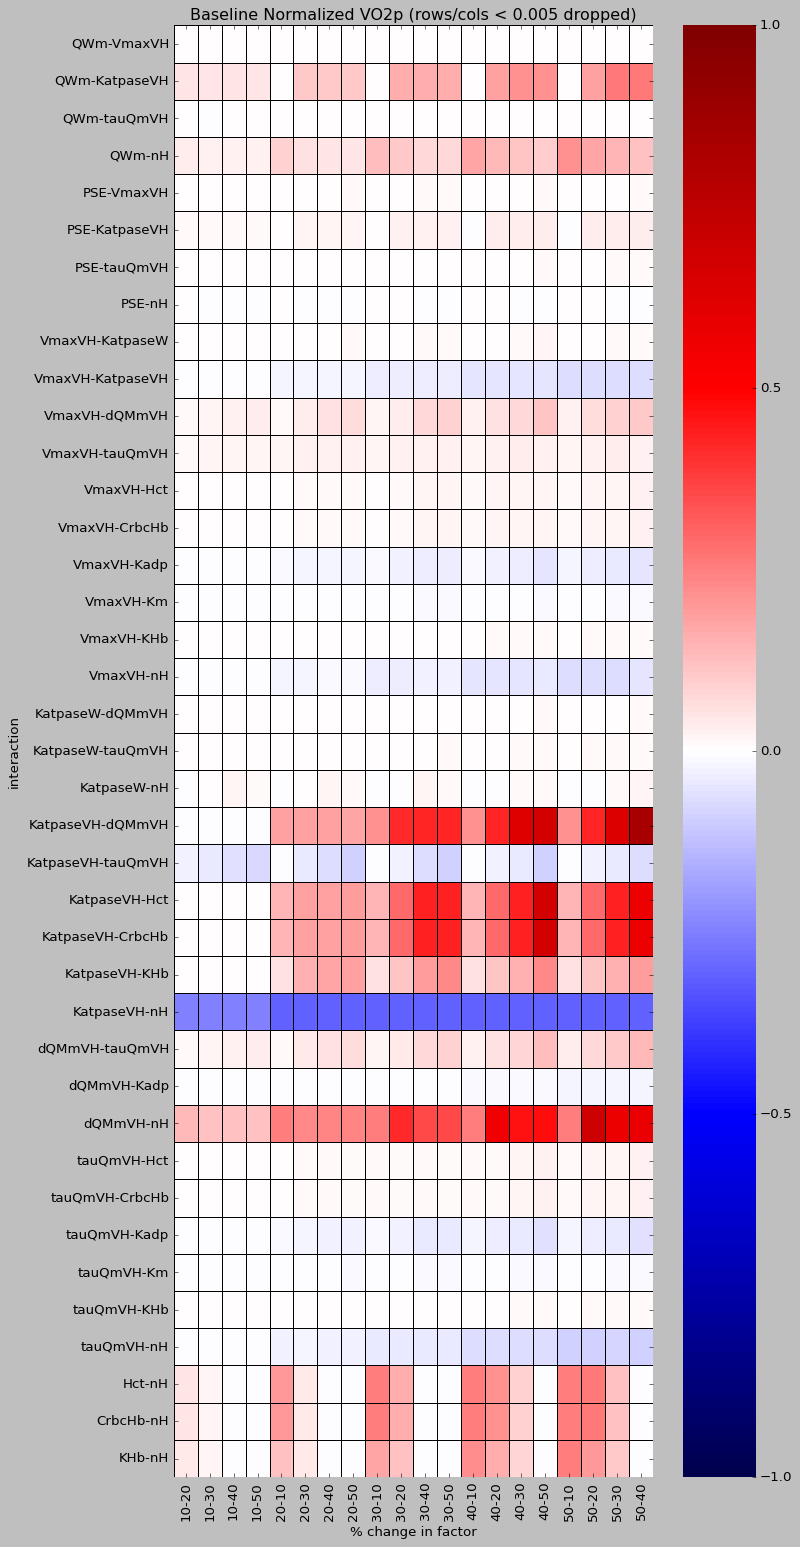

In [ ]:
def plot_interaction_heatmap(doe_2way, title=None ):
    # Normalize
    plot_df = doe_2way.beta_df / doe_2way.mu

    # Define threshold
    threshold = 0.005

    # Keep all values, but drop rows/columns only if *all* entries are below threshold
    rows_to_keep = (plot_df.abs() >= threshold).any(axis=1)
    cols_to_keep = (plot_df.abs() >= threshold).any(axis=0)

    plot_df_filtered = plot_df.loc[rows_to_keep, cols_to_keep]

    # Auto-scale figure size
    n_rows, n_cols = plot_df_filtered.shape
    fig_width = max(8, n_cols * 0.5)
    fig_height = max(6, n_rows * 0.5)

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(plot_df_filtered, cmap="seismic", center=0, vmin=-1, vmax=1,
                fmt=".2f", linewidths=0.5, linecolor="black")
    plt.title(f"Baseline Normalized {title} (rows/cols < {threshold} dropped)")
    plt.xlabel("% change in factor")
    plt.ylabel("interaction")
    plt.tight_layout()
    plt.show()

# Tests
plot_interaction_heatmap(doe_2way_VO2m, "VO2m")
plot_interaction_heatmap(doe_2way_VO2p, "VO2p")

**Results**



The baseline normalized VO2m interaction heatmap shows how muscle oxygen consumption responds when two parameters are perturbed simultaneously across a range of percent changes. Most interaction pairs produce minimal shifts, but several stand out with consistent and directional effects. KatpaseVH interacting with nH, dQMmVH, or tauQmVH leads to strong negative responses, with deep blue shading across multiple percent intervals, indicating reduced oxygen consumption. In contrast, a majority of pairs interacting with KatpaseVH show positive deviations, with red cells suggesting increased oxygen use. The percent change axis reveals that these effects are not isolated to a single perturbation range. For example, KatpaseVH–nH remains strongly negative across "10–20", "30–40", and "50–10", while QWm–KatpaseVH shows positive shifts.


The baseline normalized VO2p interaction heatmap does the same but shows how tissue oxygen consumption responsed over simultaneous perturbations of parameters across percent changes. It also demonstrated minimal shifts in interatctions, but there are a few combinations that have consistent and directional effects. This includes KatpaseVH as they have a strong positive intereaction throughout the parameter pairings minus KatpaseVH-nH which is strongly negative. nH interactions are also shown as a big factor, positively shifting oxygen consumption over the changes in factor.

#Discussion


This computational study examined how perturbations in physiological parameters influence oxygen consumption in muscle (VO2m) and tissue (VO2p). A one-way design of experiments (DOE) revealed that most individual factors had minimal impact, while KatpaseVH and nH consistently produced strong shifts, which have central roles with ATP demand and hemoglobin. Interaction heatmaps extended the analysis to paired perturbations, showing that combined changes amplified effects, especially in VO2p.

Refined VO2m interaction heatmaps from a two‑way DOE was used to determine combinations were meaningful. KatpaseVH interacting with nH, dQMmVH, or tauQmVH produced consistent negative shifts, while QWm–KatpaseVH and PSE–KatpaseVH showed positive deviations. These results reinforce the influence of ATP demand and hemoglobin unloading as dominant regulators of muscle oxygen uptake. In parallel, the VO2p two‑way DOE revealed that tissue oxygen consumption is shaped by similar dynamics. Most parameter pairs produced minimal changes, but like the VO2m, KatpaseVH interactions dominated the pattern. Nearly all of its pairings drove positive shifts in VO2p while KatpaseVH–nH remained strongly negative across multiple ranges. Beyond this, nH interactions with other parameters generally increased VO2p. The only differences between VO2m and VO2p is the effectiveness, where parameters had larger impacts on VO2p. Overall, the same mechanisms identified in VO2m also govern tissue‑level oxygen consumption (VO2p) but at different degrees.

These findings directly support the new study question: how do vascular and cardiac impairments translate into measurable reductions in oxygen consumption? As mentioned earlier, cardiac and vascular illnesses reduce cardiac output that comprimises oxygen delivery and can damage vasculature that compromises oxygen diffusion. The results highlight ATP demand (KatpaseVH), blood flow dynamics (dQMmVH), and hemoglobin unloading (nH) as the most sensitive drivers of oxygen consumption. In identifying these parameters, steps can be made to pinpoint mechanisms that constrain oxygen delivery under stress. This study can be used to develop strategies for managing vascular and cardiac limitations. Exercise protocols can be tailored to specific physiological constraints, enabling individualized rehabilitation. The sensitivity analysis also highlights candidate biomarkers like hemoglobin cooperativity and ATPase activity that could serve as predictive indicators for disease severity and progression. This model connects biomechanical/chemical systems and can be applied for translational applications.